# **EXPLORING JOB DISSATISFACTION IN THE UK USING REDDIT DATA (2025 Dataset)**

## **AN NLP-BASED THEMATIC AND SENTIMENT ANALYSIS**


### **Student Name**: Awopetu Rasheed Oluwadamilare

### **Student Number**: 202432121

### **Library Installation**

In [1]:
pip install praw pandas tqdm python-dotenv emoji vaderSentiment textblob wordcloud pyLDAvis gensim bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.8 MB/s eta 0:00:00


### **Import the necessary libraries**

In [25]:
import pandas as pd
import os, time, json
import praw
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re, emoji, nltk, spacy
import torch
import pyLDAvis
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


from gensim.corpora.dictionary import Dictionary
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap.umap_ import UMAP
from hdbscan import HDBSCAN
from dotenv import load_dotenv
from datetime import datetime, timedelta
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from nltk.corpus import stopwords
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from datetime import datetime, timedelta
import time
import pandas as pd
from tqdm import tqdm
from prawcore.exceptions import TooManyRequests
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


### **Loading Environment Variable from .env File**

##### To keep Reddit API credentials secure, we store them in a `.env` file instead of hardcoding into the script. So anytime we need them we can easily pass them to the reddit API easily

In [ ]:
environment_variable = load_dotenv()
if environment_variable:
    print("Environment variables loaded successfully.")
else:
    print("Failed to load environment variables. Please Upload .env file")

Environment variables loaded successfully.


### **Loading Dataset & Data Collection**

We will collects Reddit posts and comments related to **job dissatisfaction & Satisfaction in the UK**.  
- Subreddits: `ukjobs`, `AskUK`, `CasualUK`, `unitedkingdom`, `britishproblems`, `antiwork`, `antiwork`, `WorkReform`, `careerguidance`, `AskHR`, `britishproblems`,.  
- Queries: dissatisfaction terms (e.g., *"hate my job"*, *"toxic workplace"*) and satisfaction terms (e.g., *"love my job"*).  
- UK filter ensures posts are from UK-focused subs or mention UK places.  
- Data Period Lenght: last **9 months and 25 days** of activity. **January 2025 to October 25**  
- Output: two CSV files (`reddit_posts_uk_jobs.csv`, `reddit_comments_uk_jobs.csv`).

##### Firstly, let create a subreddit list that we intend to use.

In [ ]:
SUBREDDITS = [
    "UKJobs", "AskUK", "CasualUK", "unitedkingdom", "antiwork", "WorkReform",
    "careerguidance", "AskHR", "britishproblems", "recruitinghell", "WorkReformUK"
]

print(f"List of subreddits: {(SUBREDDITS)}")

List of subreddits: ['UKJobs', 'AskUK', 'CasualUK', 'unitedkingdom', 'antiwork', 'WorkReform', 'careerguidance', 'AskHR', 'britishproblems', 'recruitinghell', 'WorkReformUK']


##### **Query Terms**

Two sets of keyword queries were defined to guide Reddit searches:  

- **Job Dissatisfaction** → phrases like *"hate my job"*, *"toxic workplace"*, *"low pay"*, *"burnout"*, *"bad boss"*, and *"bullying at work"*.  
- **Job Satisfaction** → phrases like *"love my job"*, *"happy at work"*, *"good boss"*, *"work life balance"*, and *"fair pay"*.  

These terms ensure we capture a broad range of posts expressing both negative and positive experiences with work in the UK.

In [ ]:
DISSATISFACTION_TERMS = [
    "job dissatisfaction", "hate my job", "toxic workplace", "burnout", "overworked",
    "bad boss", "micromanagement", "low pay", "underpaid", "quit my job", "resign",
    "stress at work", "bullying at work", "zero hours", "unhappy at work", "stressful job", "poor management", "burnt out", "miserable at work",
    "dead-end job", "exploited at work", "no work-life balance", "hate going to work", "rejection", "really bad", "unreasonable", "management cuts benefits"
]

print(f"List of Dissatisfaction terms: {(DISSATISFACTION_TERMS)}")

List of Dissatisfaction terms: ['job dissatisfaction', 'hate my job', 'toxic workplace', 'burnout', 'overworked', 'bad boss', 'micromanagement', 'low pay', 'underpaid', 'quit my job', 'resign', 'stress at work', 'bullying at work', 'zero hours', 'unhappy at work', 'stressful job', 'poor management', 'burnt out', 'miserable at work', 'dead-end job', 'exploited at work', 'no work-life balance', 'hate going to work', 'rejection', 'really bad', 'unreasonable', 'management cuts benefits']


In [ ]:
SATISFACTION_TERMS = [
    "love my job", "happy at work", "good boss", "great team", "work life balance",
    "supportive manager", "flexible working", "fair pay"
]
print(f"List of Satisfaction terms: {(SATISFACTION_TERMS)}")

List of Satisfaction terms: ['love my job', 'happy at work', 'good boss', 'great team', 'work life balance', 'supportive manager', 'flexible working', 'fair pay']


##### A regex filter **(`UK_REGEX`)** was applied to retain only posts from UK-focused subreddits or those mentioning UK locations (e.g., London, Manchester, Scotland).

In [ ]:
UK_REGEX = re.compile(r"\b(UK|United Kingdom|England|Scotland|Wales|Northern Ireland|London|Manchester|Birmingham|Leeds|Glasgow|Bristol|Liverpool)\b", re.IGNORECASE)

##### Posts were collected from the **last 326 days (Approximately 11 months, 23 Days)** to capture recent discussions on job dissatisfaction and satisfaction in the UK.

In [ ]:
DAYS_BACK = 326

##### **Reddit API Authentication** -> Access to Reddit data was established using the **PRAW (Python Reddit API Wrapper)** library.  Authentication requires three environment variables loaded from the `.env` file:

In [ ]:
reddit = praw.Reddit(client_id=os.getenv("CLIENT_ID"), client_secret=os.getenv("CLIENT_SECRET"), user_agent=os.getenv("USER_AGENT"), check_for_async=False, )

##### A helper function was used to retain only posts from UK-focused subreddits or those mentioning UK locations.  

In [ ]:
def is_uk_related(text: str, subreddit: str) -> bool:
    if subreddit.lower() in {"ukjobs", "askuk", "casualuk", "unitedkingdom", "britishproblems"}:
        return True
    return bool(UK_REGEX.search(text or ""))

##### A custom function was used to search target subreddits with defined queries, filter by UK relevance and time window, and return labelled posts with top-level comments for analysis.  

#### **Push shift documentation** -> https://github.com/pushshift/api

In [ ]:
def search_and_collect(queries, label):
    """
    Search posts for each query across target subreddits, INCLUDE metadata AND top comments.
    label = 'dissatisfaction' or 'satisfaction'
    """
    since = int((datetime.utcnow() - timedelta(days=DAYS_BACK)).timestamp())
    rows_posts, rows_comments = [], []

    for sr in SUBREDDITS:
        sub = reddit.subreddit(sr)
        for q in queries:
            results = sub.search(q, sort="new", limit=500)
            for s in tqdm(results, desc=f"{sr} | {q}"):
                if s.created_utc < since:
                    continue

                # UK filter
                blob = f"{s.title}\n{s.selftext or ''}"
                if not is_uk_related(blob, sr):
                    continue

                post_row = {
                    "id": s.id,
                    "subreddit": sr,
                    "created_utc": s.created_utc,
                    "created_iso": datetime.utcfromtimestamp(s.created_utc).isoformat(),
                    "author": str(s.author) if s.author else None,
                    "title": s.title,
                    "selftext": s.selftext,
                    "score": s.score,
                    "num_comments": s.num_comments,
                    "url": s.url,
                    "permalink": f"https://www.reddit.com{s.permalink}",
                    "query": q,
                    "label": label,
                    "source": "reddit_api",
                }
                rows_posts.append(post_row)

                s.comment_sort = "top"
                s.comments.replace_more(limit=0)
                for c in s.comments[:25]:
                    rows_comments.append({
                        "post_id": s.id,
                        "comment_id": c.id,
                        "created_utc": c.created_utc,
                        "created_iso": datetime.utcfromtimestamp(c.created_utc).isoformat(),
                        "author": str(c.author) if c.author else None,
                        "body": c.body,
                        "score": c.score,
                        "permalink": f"https://www.reddit.com{c.permalink}",
                        "subreddit": sr,
                        "post_query": q,
                        "post_label": label,
                    })

                time.sleep(0.6)
    return pd.DataFrame(rows_posts), pd.DataFrame(rows_comments)

###### **Data Collection and Storage**
The script collects Reddit posts for both dissatisfaction and satisfaction queries, merges and de-duplicates results, and saves labelled posts and comments as CSV files for subsequent NLP, sentiment, and thematic analysis.  

In [ ]:
if __name__ == "__main__":
    posts_diss, comments_diss = search_and_collect(DISSATISFACTION_TERMS, "dissatisfaction")
    posts_sat,  comments_sat  = search_and_collect(SATISFACTION_TERMS, "satisfaction")

    posts = pd.concat([posts_diss, posts_sat], ignore_index=True)
    posts = posts.drop_duplicates(subset=["id"])
    comments = pd.concat([comments_diss, comments_sat], ignore_index=True)
    comments = comments.drop_duplicates(subset=["comment_id"])

    os.makedirs("data", exist_ok=True)
    posts.to_csv("data/reddit_posts_uk_jobs.csv", index=False)
    comments.to_csv("data/reddit_comments_uk_jobs.csv", index=False)

    print("Saved data/reddit_posts_uk_jobs.csv and data/reddit_comments_uk_jobs.csv")

UKJobs | job dissatisfaction: 12it [00:02,  4.77it/s]
UKJobs | hate my job: 225it [02:50,  1.32it/s]
UKJobs | toxic workplace: 68it [00:16,  4.03it/s]
UKJobs | burnout: 84it [00:28,  3.00it/s]
UKJobs | overworked: 73it [00:14,  5.16it/s]
UKJobs | bad boss: 151it [00:36,  4.17it/s]
UKJobs | micromanagement: 112it [00:38,  2.90it/s]
UKJobs | low pay: 231it [02:28,  1.56it/s]
UKJobs | underpaid: 228it [01:15,  3.01it/s]
UKJobs | quit my job: 238it [03:17,  1.21it/s]
UKJobs | resign: 236it [02:29,  1.58it/s]
UKJobs | stress at work: 241it [03:20,  1.20it/s]
UKJobs | bullying at work: 107it [00:31,  3.41it/s]
UKJobs | zero hours: 188it [00:55,  3.40it/s]
UKJobs | unhappy at work: 109it [00:33,  3.29it/s]
UKJobs | stressful job: 243it [03:21,  1.20it/s]
UKJobs | poor management: 221it [01:01,  3.62it/s]
UKJobs | burnt out: 185it [00:56,  3.26it/s]
UKJobs | miserable at work: 121it [00:29,  4.09it/s]
UKJobs | dead-end job: 207it [00:57,  3.59it/s]
UKJobs | exploited at work: 21it [00:09,  2.3

Saved data/reddit_posts_uk_jobs.csv and data/reddit_comments_uk_jobs.csv


###### We are using pandas to load two CSV files. One with Reddit posts and another with comments from the UK jobs subreddit. We let pandas handle any tricky line breaks and skip over bad lines so nothing breaks while loading. In the end, we just print out the number of rows and columns to get a quick feel for how big our datasets are.

In [ ]:
posts = pd.read_csv("data/reddit_posts_uk_jobs.csv", lineterminator='\n')
comments = pd.read_csv("data/reddit_comments_uk_jobs.csv", lineterminator='\n', on_bad_lines='skip')

print("Posts:", posts.shape)
print("Comments:", comments.shape)

Posts: (5498, 14)
Comments: (62452, 11)


### **CSV File combined**

###### Let **combined the 2 datset** together so we can be able to work with a single dataset

###### We’re adding a new column called source to both our datasets. We let the posts have the label "post" and the comments have the label "comment". This way, when we eventually combine or analyze everything together, we’ll know exactly which entries came from posts and which came from comments.

In [ ]:
posts["source"] = "post"
comments["source"] = "comment"

###### For the posts, we fill in any missing titles or selftexts with empty strings, then combine them into one column called text_raw so each post has a single block of text. For the comments, we fill any missing body text with an empty string and store it in text_raw as well.

In [ ]:
posts["title"] = posts["title"].fillna("")
posts["selftext"] = posts["selftext"].fillna("")
posts["text_raw"] = (posts["title"] + " " + posts["selftext"]).str.strip()

comments["body"] = comments["body"].fillna("")
comments["text_raw"] = comments["body"]

###### Streamlining our data by keeping only the most important columns. For the posts, we select useful fields like the post ID, subreddit, author, text, score, and a few others that we’ll need for analysis. For the comments, we first rename some columns like changing comment_id to id, post_query to query, and post_label to label so they match the posts dataset. Then, we keep the same set of columns as in the posts DataFrame. This makes both datasets consistent and ready to be combined or compared later on.

In [ ]:
# Columns to keep for posts
posts_small = posts[[
    "id","subreddit","created_utc","author","text_raw","score",
    "query","label","source","permalink"
]]

# Columns to keep for comments
comments_small = comments.rename(columns={
    "comment_id": "id",
    "post_query": "query",
    "post_label": "label"
})[[
    "id","subreddit","created_utc","author","text_raw","score",
    "query","label","source","permalink"
]]

###### We use pd.concat() to stack them together and set ignore_index=True so the index resets automatically. After merging, we print out the new dataset’s shape to see how big it is, and then display the first few rows with dataset.head() to make sure everything looks right.

In [ ]:
dataset = pd.concat([posts_small, comments_small], ignore_index=True)
print("Combined dataset shape:", dataset.shape)
dataset.head()

Combined dataset shape: (67950, 10)


,id,subreddit,created_utc,author,text_raw,score,query,label,source,permalink
0,1ltd0pl,UKJobs,1.751838e+09,ZealousidealFig5,Is there a correlation between unemployment an...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...
1,1l28f88,UKJobs,1.748947e+09,ZebraShark,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1l28f...
2,1k1kp8i,UKJobs,1.744916e+09,VegetaGuy,Looking for advice Going to try condense this ...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...
3,1p6jdj5,UKJobs,1.764093e+09,Express-Camera9657,Struggling to pick a career path because I fee...,3,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...
4,1p6cgeh,UKJobs,1.764077e+09,Odiseeadark06,I hate my new job and am thinking to leave I s...,25,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...


##### Saving the combined dataset so we can use it in our sentiment analysis

In [ ]:
dataset.to_csv('2025_JOB_Dissatisfaction.csv', index=False)

#### **Loading Saved Dataset**

###### We’re importing our dataset from a CSV file and taking a quick look at the top few records to get familiar with the structure of the data before we dive into analysis.

In [ ]:
Dataset = pd.read_csv('2025_JOB_Dissatisfaction.csv')
Dataset.head()

,id,subreddit,created_utc,author,text_raw,score,query,label,source,permalink
0,1ltd0pl,UKJobs,1.751838e+09,ZealousidealFig5,Is there a correlation between unemployment an...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...
1,1l28f88,UKJobs,1.748947e+09,ZebraShark,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1l28f...
2,1k1kp8i,UKJobs,1.744916e+09,VegetaGuy,Looking for advice Going to try condense this ...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...
3,1p6jdj5,UKJobs,1.764093e+09,Express-Camera9657,Struggling to pick a career path because I fee...,3,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...
4,1p6cgeh,UKJobs,1.764077e+09,Odiseeadark06,I hate my new job and am thinking to leave I s...,25,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...


### **Data Exploration**

###### Let's examining and understanding our dataset before doing any analysis or modeling.

##### **Displaying basic info of the Dataset**

In [ ]:
print(Dataset.shape)

(67950, 10)


In [ ]:
print(Dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67950 entries, 0 to 67949
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           67950 non-null  object 
 1   subreddit    67950 non-null  object 
 2   created_utc  67950 non-null  float64
 3   author       63621 non-null  object 
 4   text_raw     67950 non-null  object 
 5   score        67950 non-null  int64  
 6   query        67950 non-null  object 
 7   label        67950 non-null  object 
 8   source       67950 non-null  object 
 9   permalink    67950 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 5.2+ MB
None


##### **Checking Missing Value**

In [ ]:
print(Dataset.isnull().sum())

id                0
subreddit         0
created_utc       0
author         4329
text_raw          0
score             0
query             0
label             0
source            0
permalink         0
dtype: int64


###### From the dataset we discover we only have NAN only in the author role and also we have 1 NAN is text_raw. all this will be cleaned during the Data Cleaning Process

##### **Checking for Duplicates**

In [ ]:
print(Dataset.duplicated(subset=['text_raw']).sum())

5970


###### We discovered that we have 5,970 Duplicates in our Dataset. We are going to remove all this duplicates during the data cleaning

###### Let check our `label` field that we go from the **Reddit API**  

In [ ]:
print(Dataset['label'].value_counts())

label
dissatisfaction    51604
satisfaction       16346
Name: count, dtype: int64


###### We clearly discovered that we have 51,604 data that is related to dissatisfaction and 16,346 data that relate to satisfaction.

/tmp/ipython-input-7856422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])


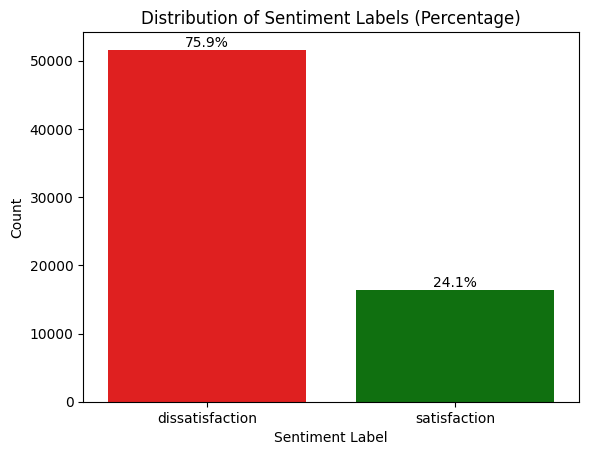

In [ ]:
ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])

total = len(Dataset)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribution of Sentiment Labels (Percentage)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

##### Let explore data based on Subreddit

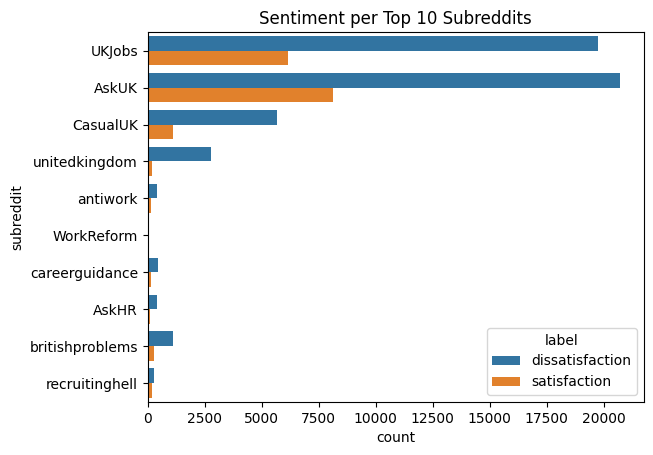

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
sns.countplot(y='subreddit', hue='label', data=Dataset[Dataset['subreddit'].isin(top_subs)])
plt.title('Sentiment per Top 10 Subreddits')
plt.show()

###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_table = pd.crosstab(top_data['subreddit'], top_data['label'])
display(sentiment_table)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,424,93
AskUK,20725,8117
CasualUK,5650,1105
UKJobs,19758,6143
WorkReform,49,0
antiwork,408,126
britishproblems,1115,256
careerguidance,443,125
recruitinghell,271,177


###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare using the percentage

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(10).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_percent = pd.crosstab(top_data['subreddit'], top_data['label'], normalize='index') * 100
sentiment_percent = sentiment_percent.round(1)
display(sentiment_percent)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,82.0,18.0
AskUK,71.9,28.1
CasualUK,83.6,16.4
UKJobs,76.3,23.7
WorkReform,100.0,0.0
antiwork,76.4,23.6
britishproblems,81.3,18.7
careerguidance,78.0,22.0
recruitinghell,60.5,39.5


###### Let’s create word clouds to visualize what people talk about most comparing positive (satisfaction) and negative (dissatisfaction) words side by side

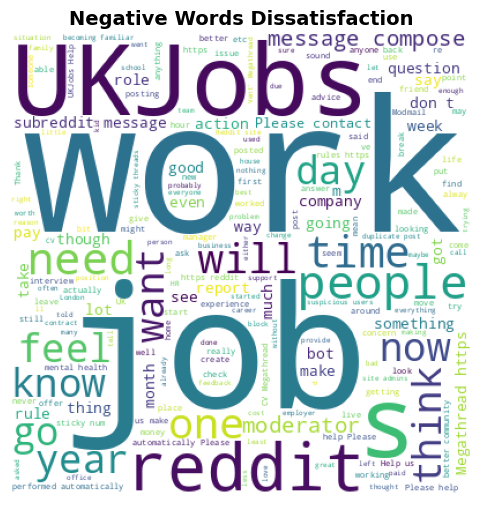

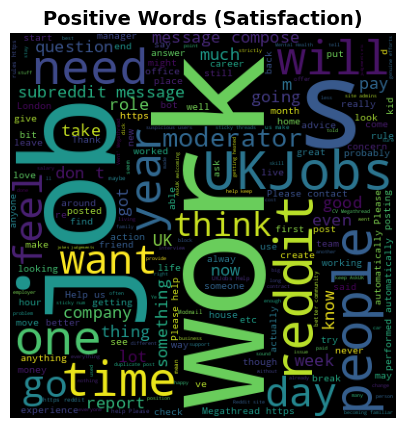

In [ ]:
pos_text = ' '.join(Dataset[Dataset['label']=='satisfaction']['text_raw'])
neg_text = ' '.join(Dataset.loc[Dataset['label'] == 'dissatisfaction', 'text_raw'].dropna().astype(str))

plt.figure(figsize=(6, 6))
plt.imshow(WordCloud(width=400, height=400, background_color='white').generate(neg_text))
plt.title('Negative Words Dissatisfaction', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400, height=400).generate(pos_text))
plt.title('Positive Words (Satisfaction)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.show()

###### **Frequency of each unique based on Query**

Unique queries: ['job dissatisfaction' 'hate my job' 'toxic workplace' 'burnout'
 'overworked' 'bad boss' 'micromanagement' 'low pay' 'underpaid'
 'quit my job' 'resign' 'stress at work' 'bullying at work' 'zero hours'
 'unhappy at work' 'stressful job' 'poor management' 'burnt out'
 'miserable at work' 'dead-end job' 'exploited at work'
 'no work-life balance' 'hate going to work' 'rejection' 'really bad'
 'unreasonable' 'management cuts benefits' 'love my job' 'happy at work'
 'good boss' 'great team' 'work life balance' 'supportive manager'
 'flexible working' 'fair pay']


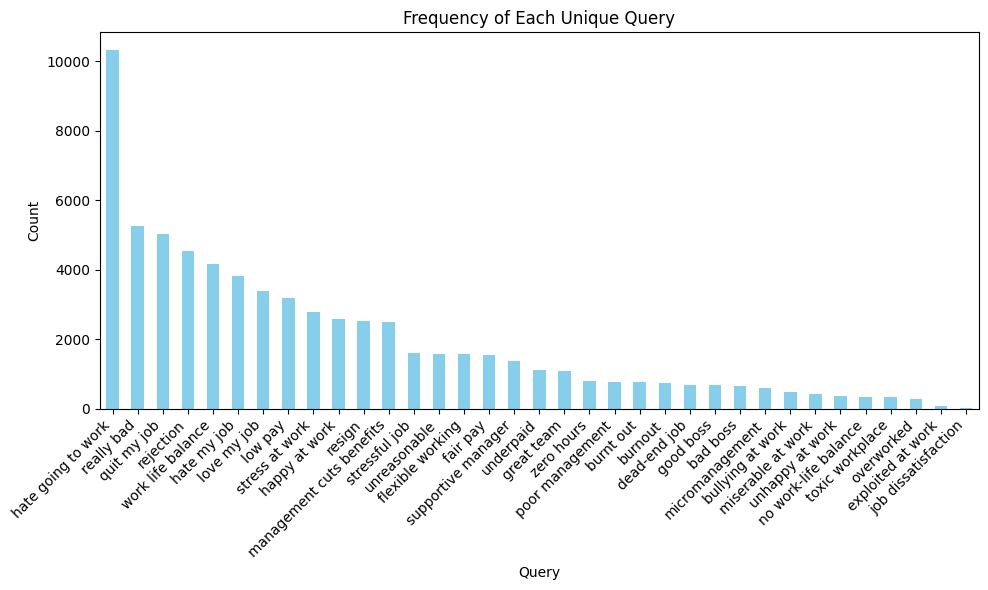

In [ ]:
query_counts = Dataset['query'].value_counts()

print("Unique queries:", Dataset['query'].unique())

plt.figure(figsize=(10, 6))
query_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Each Unique Query')
plt.xlabel('Query')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###### **Let display a chart based on the source**

Unique queries: ['post' 'comment']


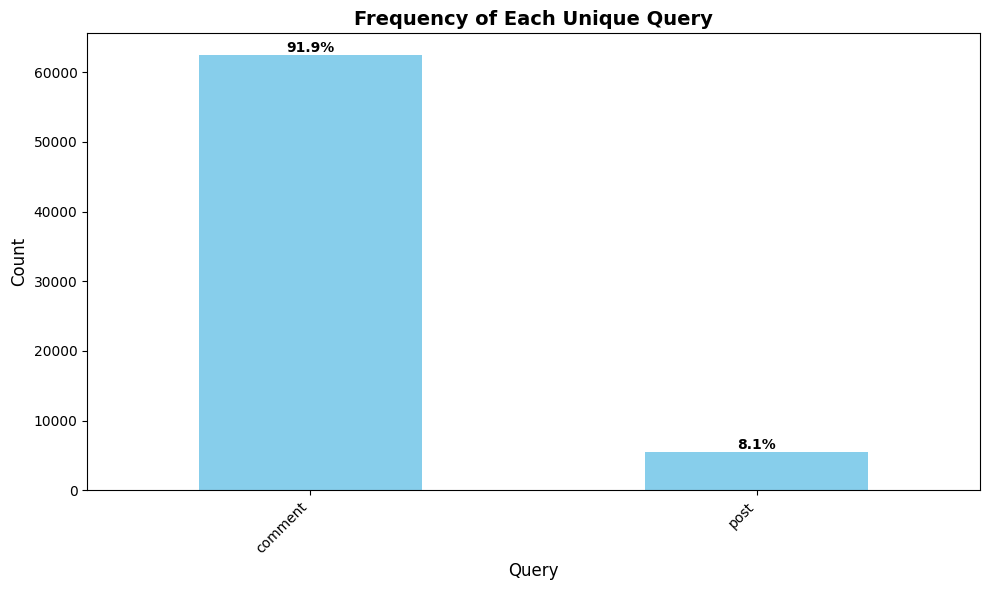

In [ ]:
query_counts = Dataset['source'].value_counts()

print("Unique queries:", Dataset['source'].unique())

total = query_counts.sum()

plt.figure(figsize=(10, 6))
ax = query_counts.plot(kind='bar', color='skyblue')

for i, count in enumerate(query_counts):
    percent = 100 * count / total
    ax.text(i, count + 0.5, f'{percent:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Frequency of Each Unique Query', fontsize=14, fontweight='bold')
plt.xlabel('Query', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **Data Cleaning**

###### Removing the column with [Removed] and [Deleted] columns

In [ ]:
print("Row before cleaning:", len(Dataset))

Dataset = Dataset[~Dataset['text_raw'].isin(['[deleted]', '[removed]'])]
Dataset = Dataset[~Dataset['text_raw'].str.lower().str.strip().isin(['[deleted]', '[removed]'])]
Dataset = Dataset.reset_index(drop=True)

print("Remaining rows after cleaning:", len(Dataset))


Row before cleaning: 67950
Remaining rows after cleaning: 66684


###### Drop rows with missing or empty text

In [ ]:
print("Row before dropping missing/empty text:", len(Dataset))

Dataset = Dataset[Dataset['text_raw'].notnull() & (Dataset['text_raw'].str.strip() != '')]

print("Row After dropping missing/empty text:", len(Dataset))

Row before dropping missing/empty text: 66684
Row After dropping missing/empty text: 66684


###### **Let handle the NAN Value**

In [ ]:
print(Dataset.isnull().sum())

id                0
subreddit         0
created_utc       0
author         3063
text_raw          0
score             0
query             0
label             0
source            0
permalink         0
dtype: int64


###### We found 3,063 missing values in the *author* column. Since Reddit usernames are mostly anonymous and not useful for our training, we’ll simply drop this column.

In [ ]:
Dataset = Dataset.drop('author', axis=1)

In [ ]:
print(Dataset.isnull().sum())

id             0
subreddit      0
created_utc    0
text_raw       0
score          0
query          0
label          0
source         0
permalink      0
dtype: int64


###### Now our Author Column have been dropped and we currently don't have any nan in our Dataset.

###### Now, let’s clean our **text_raw** data by converting everything to lowercase, removing URLs and emojis, filtering out stopwords, and applying lemmatization to make the text neat and consistent!


In [ ]:
nltk.download("stopwords")
EN_STOP = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm", exclude=["ner","parser","textcat"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # lowercase
    text = emoji.replace_emoji(text, replace=" ")   # remove emojis
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^\w\s']", " ", text)          # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize(text):
    doc = nlp(text)
    return " ".join(
        tok.lemma_ for tok in doc
        if tok.lemma_ not in EN_STOP and tok.is_alpha
    )

Dataset["text_clean"] = Dataset["text_raw"].apply(clean_text)
Dataset["text_lemma"] = Dataset["text_clean"].apply(lemmatize)

print("Cleaned & lemmatized posts and comments")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cleaned & lemmatized posts and comments


###### We have successfully cleaned our dataset. Let **Preview** it and move on to the **Sentiment analysis**

In [ ]:
display(Dataset.head())

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma
0,1ltd0pl,UKJobs,1.751838e+09,Is there a correlation between unemployment an...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...,is there a correlation between unemployment an...,correlation unemployment number job applicant ...
1,1l28f88,UKJobs,1.748947e+09,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1l28f...,me and a colleague have been shortlisted for s...,I colleague shortlist role make I nervous coll...
2,1k1kp8i,UKJobs,1.744916e+09,Looking for advice Going to try condense this ...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...,looking for advice going to try condense this ...,look advice go try condense much possible othe...
3,1p6jdj5,UKJobs,1.764093e+09,Struggling to pick a career path because I fee...,3,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...,struggling to pick a career path because i fee...,struggle pick career path I feel like I could ...
4,1p6cgeh,UKJobs,1.764077e+09,I hate my new job and am thinking to leave I s...,25,hate my job,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...,i hate my new job and am thinking to leave i s...,I hate new job think leave I start new job wee...


In [ ]:
Dataset.to_csv('2025_JOB_Dissatisfaction_Cleaned.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2025_JOB_Dissatisfaction_Cleaned.csv')

### **Sentiment Analysis**

##### Sentiment analysis is a natural language processing technique that identifies and classifies emotions or opinions in text as positive, negative, or neutral. It helps organizations understand customer feedback, social media posts, or reviews. Using machine learning, it automates the process of interpreting human emotions for better decision-making and communication.


### **Reddit Label**

###### Let’s rename our sentiment labels for clarity changing *satisfaction* to **Positive** and *dissatisfaction* to **Negative**, then count how many posts fall into each category

In [ ]:
Dataset['label'] = Dataset['label'].replace('dissatisfaction', 'Negative')
Dataset['label'] = Dataset['label'].replace('satisfaction', 'Positive')
Reddit_Label = Dataset["label"].value_counts().sort_index()
print(Reddit_Label)

label
Negative    50663
Positive    16021
Name: count, dtype: int64


###### Let’s visualize the number of posts for each sentiment label with a simple bar chart to see how our data is distributed

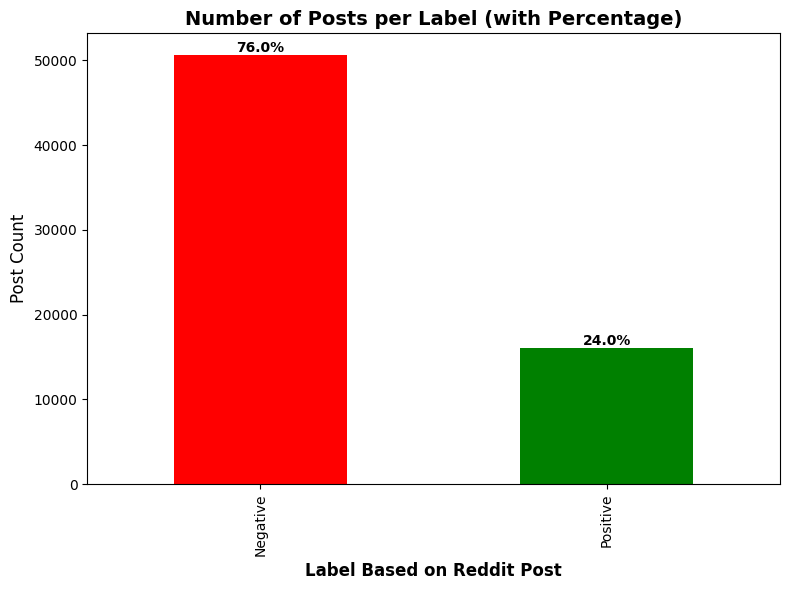

In [ ]:
plt.figure(figsize=(8, 6))
ax = Reddit_Label.plot(kind="bar", color=['red', 'green'])
total = Reddit_Label.sum()
for i, value in enumerate(Reddit_Label):
    percent = 100 * value / total
    ax.text(i, value + 0.5, f'{percent:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Number of Posts per Label (with Percentage)", fontsize=14, fontweight='bold')
plt.xlabel("Label Based on Reddit Post", fontsize=12, fontweight="bold")
plt.ylabel("Post Count", fontsize=12)
plt.tight_layout()
plt.show()

#### **Rule Based Using Vader**

###### VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for social media text. It uses a pre-built lexicon and considers word intensity, punctuation, capitalization, and emojis to determine sentiment scores positive, negative, neutral, and compound. Making it accurate for short, informal, and expressive online language.


###### Make a VADER analyzer to check how positive or negative text is

In [ ]:
analyzer = SentimentIntensityAnalyzer()

###### Let’s use the **VADER** sentiment analyzer to score each post’s emotional tone, then classify it as **Positive**, **Negative**, or **Neutral** based on the compound sentiment score.


In [ ]:
Dataset['compound'] = Dataset['text_lemma'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [ ]:
display(Dataset.head())

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma,compound
0,1ltd0pl,UKJobs,1.751838e+09,Is there a correlation between unemployment an...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...,is there a correlation between unemployment an...,correlation unemployment number job applicant ...,-0.9201
1,1l28f88,UKJobs,1.748947e+09,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1l28f...,me and a colleague have been shortlisted for s...,I colleague shortlist role make I nervous coll...,0.2516
2,1k1kp8i,UKJobs,1.744916e+09,Looking for advice Going to try condense this ...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...,looking for advice going to try condense this ...,look advice go try condense much possible othe...,0.5367
3,1p6jdj5,UKJobs,1.764093e+09,Struggling to pick a career path because I fee...,3,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...,struggling to pick a career path because i fee...,struggle pick career path I feel like I could ...,0.8779
4,1p6cgeh,UKJobs,1.764077e+09,I hate my new job and am thinking to leave I s...,25,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...,i hate my new job and am thinking to leave i s...,I hate new job think leave I start new job wee...,-0.9473


###### We have a new field called compound which was gotten from Vader. Let use the compound score to group their sentiment. According to Vader documentation. positive sentiment: compound score >= 0.05, neutral sentiment: (compound score > -0.05) and (compound score < 0.05), negative sentiment: compound score <= -0.05  

In [ ]:
Dataset['vader_sentiment'] = Dataset['vader_sentiment'] = Dataset['compound'].apply(lambda c: ('Positive' if c >= 0.05 else 'Negative' if c <= -0.05 else 'Neutral'))

###### Now we have sucessfully added the compound score and also a new column called vader sentiment which categorize them into Positive, Negative and Neutral

###### Let plot a bar chart showing how many posts are **Positive**, **Neutral**, or **Negative** according to VADER

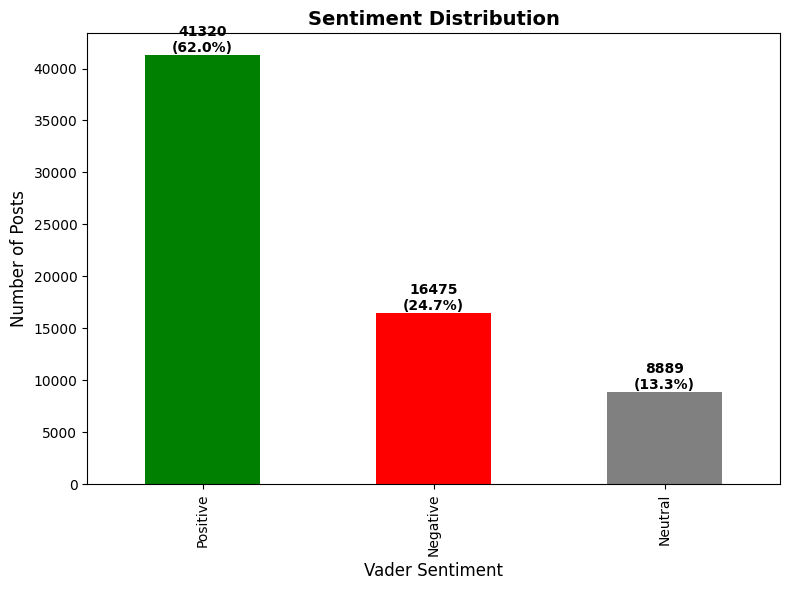

In [ ]:
sentiment_counts = Dataset['vader_sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Vader Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

###### let plot an histogram to show how the VADER compound scores are spread across all reviews

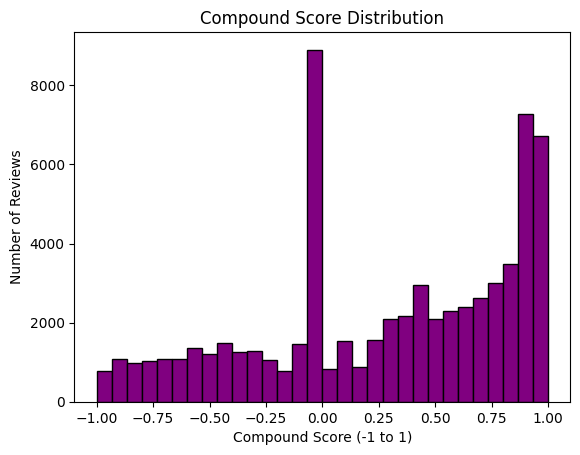

In [ ]:
plt.hist(Dataset['compound'], bins=30, color='purple', edgecolor='black')
plt.title('Compound Score Distribution')
plt.xlabel('Compound Score (-1 to 1)')
plt.ylabel('Number of Reviews')
plt.show()

###### Let create a word cloud of the most common words from positive posts

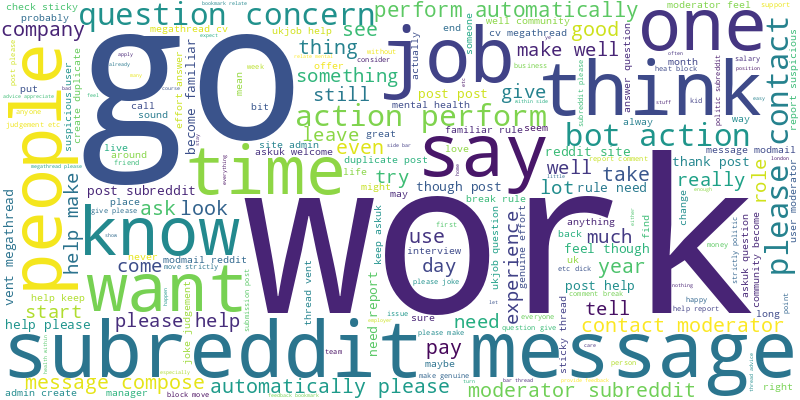

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Positive']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

WordCloud for the Negative word as well

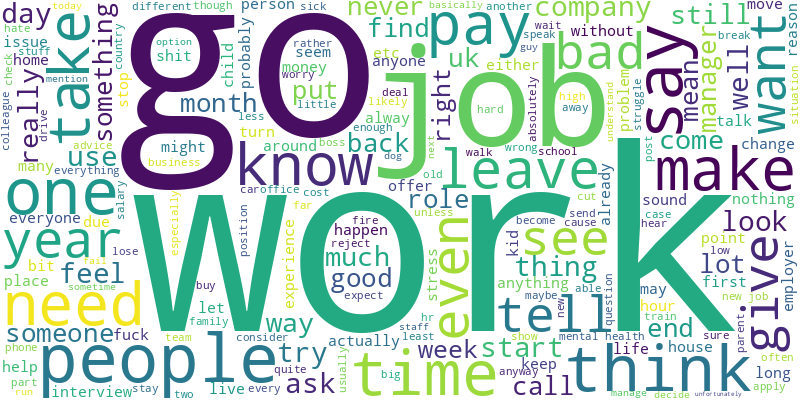

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Negative']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

###### Let print the most positive and most negative reviews based on the highest and lowest VADER compound scores

In [ ]:
print("Most Positive Review:")
print(Dataset.loc[Dataset['compound'].idxmax(), 'text_lemma'])

print("\nMost Negative Review:")
print(Dataset.loc[Dataset['compound'].idxmin(), 'text_lemma'])

Most Positive Review:
nhs england really fail I senior doctor nhs one thing I learn issue face result frontline staff fail roll sleeve try good rather much chaos stress endless crisis read daily trace back series decision make senior leadership team nhs england nhse leadership choice ripple across every trust every specialism nearly every colleague I meet shape daily experience doctor nurse ally health professional way often detrimental patient care nhs england leadership either lobby government particular policy task turn government policy reality yet never hold accountable secretary state health social care catch disproportionate amount flak contract erosion continuity care back new contract impose resident doctor market least public upgrade would introduce seven day nhs ensure consistent coverage throughout weekend practice political optic genuine improvement patient outcome perspective tangible change doctor suddenly find spread thinly across day rota pattern become erratic one gre

#### **Rule Based Using TextBlob**

###### TextBlob is a Python library for processing textual data. It provides simple APIs for tasks like sentiment analysis, part-of-speech tagging, and noun phrase extraction. Using pre-trained models, TextBlob assigns polarity (positive or negative) and subjectivity scores, making it beginner-friendly for quickly analyzing text and building natural language processing applications.


###### Let's download TextBlob's required NLTK corpora (needed for sentiment analysis, translation, etc.)

In [ ]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


###### Let calculate TextBlob sentiment scores for each text (polarity and subjectivity) and also display the first few rows to check the new columns

In [ ]:
Dataset['polarity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)
Dataset['subjectivity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

display(Dataset.head())

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity
0,1ltd0pl,UKJobs,1.751838e+09,Is there a correlation between unemployment an...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...,is there a correlation between unemployment an...,correlation unemployment number job applicant ...,-0.9201,Negative,0.034020,0.491580
1,1l28f88,UKJobs,1.748947e+09,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1l28f...,me and a colleague have been shortlisted for s...,I colleague shortlist role make I nervous coll...,0.2516,Positive,0.262500,0.466667
2,1k1kp8i,UKJobs,1.744916e+09,Looking for advice Going to try condense this ...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...,looking for advice going to try condense this ...,look advice go try condense much possible othe...,0.5367,Positive,-0.022313,0.379697
3,1p6jdj5,UKJobs,1.764093e+09,Struggling to pick a career path because I fee...,3,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...,struggling to pick a career path because i fee...,struggle pick career path I feel like I could ...,0.8779,Positive,0.091667,0.465625
4,1p6cgeh,UKJobs,1.764077e+09,I hate my new job and am thinking to leave I s...,25,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...,i hate my new job and am thinking to leave i s...,I hate new job think leave I start new job wee...,-0.9473,Negative,-0.197931,0.486917


###### Let's define a function to label TextBlob polarity scores as Positive, Negative, or Neutral

In [ ]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

###### Apply the label_sentiment function to classify each TextBlob polarity score as Positive, Negative, or Neutral

In [ ]:
Dataset["Blob_Sentiment"] = Dataset["polarity"].apply(label_sentiment)

###### Let's count how many posts fall into each TextBlob sentiment category (Positive, Negative, Neutral)

In [ ]:
sentiment_counts = Dataset["Blob_Sentiment"].value_counts()

In [ ]:
print(sentiment_counts)

Blob_Sentiment
Positive    40821
Negative    15312
Neutral     10551
Name: count, dtype: int64


###### Let plot a bar chart showing how many reviews are Positive, Neutral, or Negative based on TextBlob sentiment

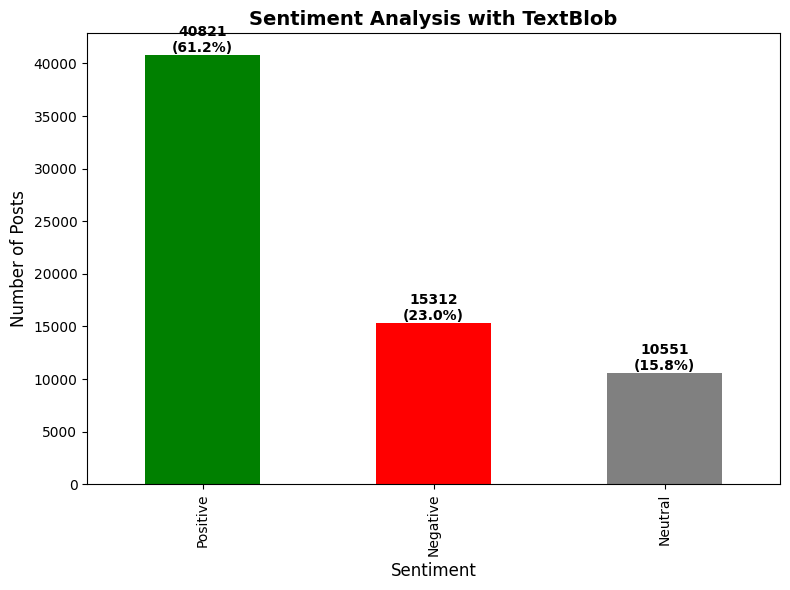

In [ ]:
sentiment_counts = sentiment_counts
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with TextBlob', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

#### **Using Transformer**

##### I loaded a Reddit-trained sentiment model and set up a pipeline to score each text in my dataset. Then I wrote a function that runs the sentiment analysis in batches, picks the highest-scoring label, and adds the sentiment results back into the dataset. Finally, I printed a small preview to check that everything worked.

In [ ]:
MODEL_NAME = "spacesedan/reddit-sentiment-analysis-longformer"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

clf = pipeline(
    task="sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True,
    max_length=128,
)

def _batch_hf_sentiment(text_series: pd.Series, batch_size: int = 64) -> pd.DataFrame:
    """
    Run HF sentiment in batches over a pandas Series of text and return
    a DataFrame with columns: neg, neu, pos, sentiment (string label).
    """
    text_series = text_series.fillna("").astype(str)

    outputs = clf(list(text_series), batch_size=batch_size)

    rows = []
    for scores in outputs:
        label_to_score = {d["label"].lower(): float(d["score"]) for d in scores}
        top_label = max(label_to_score, key=label_to_score.get)

        rows.append({
            "neg": label_to_score.get("negative"),
            "neu": label_to_score.get("neutral"),
            "pos": label_to_score.get("positive"),
            "sentiment": top_label
        })

    return pd.DataFrame(rows, index=text_series.index)

Dataset_scores = _batch_hf_sentiment(Dataset["text_lemma"])

Dataset = pd.concat([Dataset, Dataset_scores], axis=1)

print(Dataset[["text_lemma", "sentiment"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


                                          text_lemma      sentiment
0  correlation unemployment number job applicant ...        neutral
1  I colleague shortlist role make I nervous coll...       positive
2  look advice go try condense much possible othe...  very negative
3  struggle pick career path I feel like I could ...       negative
4  I hate new job think leave I start new job wee...  very negative


##### **Visualization for Transformer**

In [ ]:
display(Dataset)

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity,Blob_Sentiment,neg,neu,pos,sentiment
0,1ltd0pl,UKJobs,1.751838e+09,Is there a correlation between unemployment an...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...,is there a correlation between unemployment an...,correlation unemployment number job applicant ...,-0.9201,Negative,0.034020,0.491580,Positive,0.131145,0.563207,0.020800,neutral
1,1l28f88,UKJobs,1.748947e+09,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1l28f...,me and a colleague have been shortlisted for s...,I colleague shortlist role make I nervous coll...,0.2516,Positive,0.262500,0.466667,Positive,0.028519,0.104343,0.741285,positive
2,1k1kp8i,UKJobs,1.744916e+09,Looking for advice Going to try condense this ...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...,looking for advice going to try condense this ...,look advice go try condense much possible othe...,0.5367,Positive,-0.022313,0.379697,Negative,0.101022,0.275913,0.036717,very negative
3,1p6jdj5,UKJobs,1.764093e+09,Struggling to pick a career path because I fee...,3,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...,struggling to pick a career path because i fee...,struggle pick career path I feel like I could ...,0.8779,Positive,0.091667,0.465625,Positive,0.646834,0.135267,0.118361,negative
4,1p6cgeh,UKJobs,1.764077e+09,I hate my new job and am thinking to leave I s...,25,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...,i hate my new job and am thinking to leave i s...,I hate new job think leave I start new job wee...,-0.9473,Negative,-0.197931,0.486917,Negative,0.213474,0.009691,0.017493,very negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66679,mpohzj4,recruitinghell,1.745943e+09,Companies cheat and auto reject anyone without...,4,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,companies cheat and auto reject anyone without...,company cheat auto reject anyone without match...,-0.2960,Negative,0.250000,0.300000,Positive,0.013302,0.672179,0.006329,neutral
66680,mpo87od,recruitinghell,1.745940e+09,"Good luck, OP. Sounds just like what happened...",3,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,good luck op sounds just like what happened to...,good luck op sound like happen I gettign stem ...,0.8126,Positive,0.550000,0.500000,Positive,0.012237,0.213887,0.759691,positive
66681,mcf4fyu,recruitinghell,1.739389e+09,The discord for our subreddit can be found her...,1,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,the discord for our subreddit can be found her...,discord subreddit find feel free join realtime...,0.6249,Positive,0.250000,0.450000,Positive,0.024111,0.896784,0.007900,neutral
66682,mcimio9,recruitinghell,1.739433e+09,Yeah it's terrible. I'm in London and have bee...,2,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,yeah it's terrible i'm in london and have been...,yeah terrible I london look since june intervi...,-0.2263,Negative,-0.500000,0.500000,Negative,0.067321,0.018909,0.531621,positive


###### Because the Transformer we used is 5-point sentiment classification. we need to merge Very positive with postive and very Negative with Negative and plot our chart

In [ ]:
Dataset['sentiment'] = Dataset['sentiment'].replace('negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('positive', 'Positive')
Dataset['sentiment'] = Dataset['sentiment'].replace('neutral', 'Neutral')
Dataset['sentiment'] = Dataset['sentiment'].replace('very negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('very positive', 'Positive')

In [ ]:
Dataset['sentiment'].value_counts()

,count
sentiment,
Neutral,38988
Positive,13930
Negative,13766


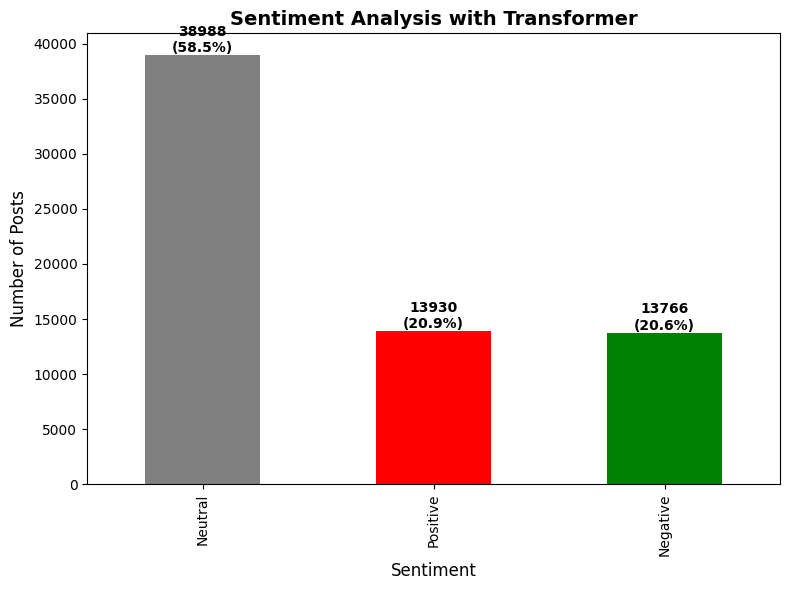

In [ ]:
sentiment_counts = Dataset['sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['gray', 'red', 'green'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

### **Comparison between Vader, TextBlob, Reddit Label and Transformer**

###### VADER handles social media text and slang better, while TextBlob is simpler, offering broader NLP features but less accurate on informal language.

###### Let's Compare the number of Positive, Neutral, and Negative sentiments between TextBlob and VADER and also Combine both results into one DataFrame for easy comparison then display them

In [ ]:
textblob_counts = Dataset["Blob_Sentiment"].value_counts()
vader_counts = Dataset["vader_sentiment"].value_counts()
Transformer_counts = Dataset["sentiment"].value_counts()

comparison = pd.DataFrame({
    "TextBlob": textblob_counts,
    "VADER": vader_counts,
    "Transformer(twitter-roberta-base-sentiment-latest)": Transformer_counts

})

display(comparison)

,TextBlob,VADER,Transformer(twitter-roberta-base-sentiment-latest)
Negative,15312,16475,13766
Neutral,10551,8889,38988
Positive,40821,41320,13930


###### Plotting a side-by-side bar chart to compare TextBlob and VADER sentiment results.

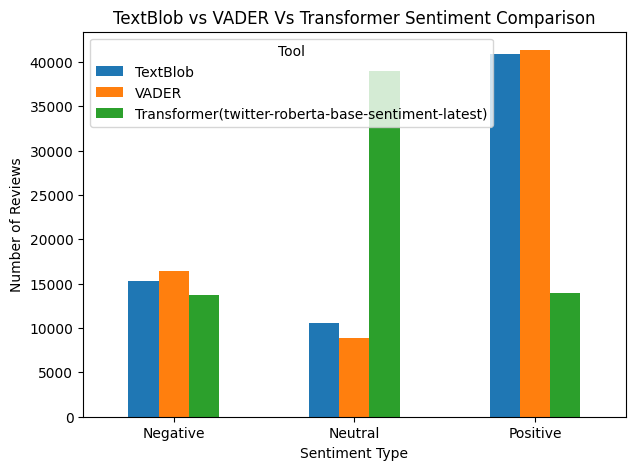

In [ ]:
comparison.plot(kind="bar", figsize=(7,5))
plt.title("TextBlob vs VADER Vs Transformer Sentiment Comparison")
plt.xlabel("Sentiment Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Tool")
plt.show()

#### **Model Agreement**

###### Let’s check how consistent our sentiment models are! We’ll see what percentage of samples all four models agree on and how often at least two models share the same sentiment.

In [ ]:
from collections import Counter

Dataset["all_agree"] = (
    (Dataset["vader_sentiment"] == Dataset["Blob_Sentiment"]) &
    (Dataset["vader_sentiment"] == Dataset["sentiment"])
)

all_agree_rate = Dataset['all_agree'].mean()

def majority_agreement(row):
    votes = [row['vader_sentiment'], row['Blob_Sentiment'], row['sentiment']]
    return len(set(votes)) < 2

Dataset['two_or_more_agree'] = Dataset.apply(majority_agreement, axis=1)
two_plus_agree_rate = Dataset['two_or_more_agree'].mean()

print(f"All 4 labelling models agree on {all_agree_rate:.2%} of samples")
print(f"At least two models agree on {two_plus_agree_rate:.2%} of samples")

All 4 labelling models agree on 25.84% of samples
At least two models agree on 25.84% of samples


#### **Average confidence**

###### Let’s evaluate how confident each sentiment model is in its predictions. We calculate absolute confidence scores for **VADER**, **TextBlob**, and the **Transformer model**, then compare their average confidence levels to see which model shows the strongest overall certainty.

In [ ]:
# VADER and TextBlob confidence (absolute values)
Dataset['vader_strength'] = Dataset['compound'].abs()
Dataset['textblob_strength'] = Dataset['polarity'].abs()

# Transformer confidence = highest probability among negative, neutral, positive
Dataset['transformer_strength'] = Dataset[['neg', 'neu', 'pos']].max(axis=1)

# Print average confidence for all three
print("Average VADER confidence:", Dataset['vader_strength'].mean())
print("Average TextBlob confidence:", Dataset['textblob_strength'].mean())
print("Average Transformer confidence:", Dataset['transformer_strength'].mean())

Average VADER confidence: 0.5312636629476336
Average TextBlob confidence: 0.16975346388870538
Average Transformer confidence: 0.6378923101146423


###### Let’s visualize the average confidence levels of our three sentiment models — **VADER**, **TextBlob**, and **Transformer** — using a clear bar chart to see which model makes predictions with the most certainty!

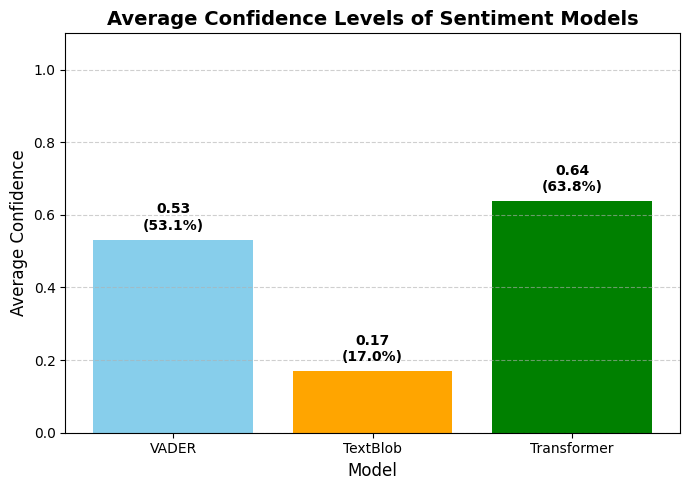

In [ ]:
avg_confidences = {
    'VADER': Dataset['vader_strength'].mean(),
    'TextBlob': Dataset['textblob_strength'].mean(),
    'Transformer': Dataset['transformer_strength'].mean()
}

plt.figure(figsize=(7, 5))
ax = plt.bar(avg_confidences.keys(), avg_confidences.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(avg_confidences.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Average Confidence Levels of Sentiment Models", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Confidence", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### The comparison of average confidence levels reveals that the Transformer model produces the strongest and most confident sentiment predictions, followed by VADER, while TextBlob shows the weakest overall confidence on the Reddit dataset.

#### **Saving the Sentiment Labelling Dataset**

In [ ]:
Dataset.to_csv('2025_JOB_Dissatisfaction_Sentiment.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2025_JOB_Dissatisfaction_Sentiment.csv')

#### **Traditional Model**

###### We will start by training with traditional model. We are using **Naive Bayes & SVM**

###### Let make a copy of our Dataset

In [ ]:
Dataframe = Dataset.copy()

#### **Naive Bayes**

#### **Naive Bayes Function**

###### So here, we’re building a balanced sentiment model. Basically, we convert our text into **TF-IDF features**, change the sentiment labels into numbers, handle **class imbalance with class weight**, train a **Naive Bayes model**, and then test how accurate it is.

In [ ]:
general_results = []

In [ ]:
Result_global = []

In [ ]:
def train_sentiment_model(dataframe, sentiment_col, use_class_weight=True):
    """
    Train a TF-IDF + MultinomialNB sentiment classifier.
    If use_class_weight=True, compute balanced class weights and pass them
    as per-sample weights to MultinomialNB.fit().
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    sample_weight_train = None
    if use_class_weight:
        classes = np.unique(y_train)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_train
        )
        class_weight_dict = {c: w for c, w in zip(classes, weights)}

        y_train_series = pd.Series(y_train).reset_index(drop=True)
        sample_weight_train = y_train_series.map(class_weight_dict).to_numpy()

        inv_label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
        pretty_weights = {
            inv_label_map[c]: round(float(w), 4)
            for c, w in class_weight_dict.items()
        }
        print("Class weights (balanced):", pretty_weights)

    # Train model
    nb = MultinomialNB()
    nb.fit(X_train, y_train, sample_weight=sample_weight_train)

    # Predict
    y_pred = nb.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive', 'Neutral']
    ))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    model_result = {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "f1_score": round(float(f1), 4),
        "use_class_weight": use_class_weight,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return nb, tfidf, accuracy, model_result

###### We’re going to train our sentiment models using the **Naive Bayes** algorithm to compare their performance. The idea is to feed in the sentiment outputs from **VADER**, **TextBlob**, and the **Transformer model** separately, and then check which one gives us the best accuracy and overall results. By doing this, we’ll be able to see which sentiment detection method works best with our dataset and produces the most reliable predictions.


#### **Vader with Naive Bayes**

In [ ]:
Dataframe['text_lemma'] = Dataframe['text_lemma'].fillna('')
Vader_Naive_Bayes = train_sentiment_model(Dataframe, 'vader_sentiment')

Class weights (balanced): {'Negative': 1.3458, 'Positive': 0.5366, 'Neutral': 2.5426}
Accuracy: 0.5637
Precision: 0.7532
F1 Score: 0.5711

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.83      0.57      3295
    Positive       0.96      0.42      0.59      8264
     Neutral       0.39      0.72      0.50      1744

    accuracy                           0.56     13303
   macro avg       0.59      0.66      0.55     13303
weighted avg       0.75      0.56      0.57     13303


Confusion Matrix (rows=true, cols=pred):
[[2743   72  480]
 [3248 3499 1517]
 [ 414   73 1257]]


#### **Transformer with Naive Bayes**

In [ ]:
Transformer_Naive_Bayes = train_sentiment_model(Dataframe, 'sentiment')

Class weights (balanced): {'Negative': 1.6106, 'Positive': 1.5916, 'Neutral': 0.5712}
Accuracy: 0.5461
Precision: 0.7541
F1 Score: 0.5668

Classification Report:
              precision    recall  f1-score   support

    Negative       0.32      0.89      0.47      2753
    Positive       0.86      0.31      0.46      2786
     Neutral       0.87      0.51      0.64      7764

    accuracy                           0.55     13303
   macro avg       0.68      0.57      0.52     13303
weighted avg       0.75      0.55      0.57     13303


Confusion Matrix (rows=true, cols=pred):
[[2455   21  277]
 [1624  863  299]
 [3694  123 3947]]


#### **Text Blob with Naive Bayes**

In [ ]:
TextBlob_Naive_Bayes = train_sentiment_model(Dataframe, 'Blob_Sentiment')

Class weights (balanced): {'Negative': 1.4481, 'Positive': 0.5431, 'Neutral': 2.1355}
Accuracy: 0.5478
Precision: 0.7533
F1 Score: 0.5456

Classification Report:
              precision    recall  f1-score   support

    Negative       0.36      0.91      0.52      3063
    Positive       0.93      0.36      0.52      8164
     Neutral       0.63      0.75      0.68      2076

    accuracy                           0.55     13303
   macro avg       0.64      0.67      0.57     13303
weighted avg       0.75      0.55      0.55     13303


Confusion Matrix (rows=true, cols=pred):
[[2788   64  211]
 [4511 2950  703]
 [ 373  154 1549]]


##### **Comparing the naive bayes result for the 4 labelling**

###### Let’s visualize how well each sentiment model performed after training with **Naive Bayes** This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling to see which one delivers the best overall results.

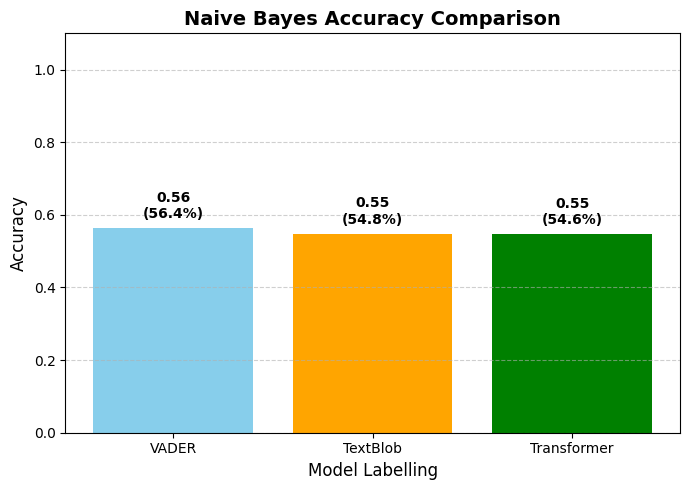

In [ ]:
Naive_Result = {
    'VADER': Vader_Naive_Bayes[2],
    'TextBlob': TextBlob_Naive_Bayes[2],
    'Transformer': Transformer_Naive_Bayes[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(Naive_Result.keys(), Naive_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(Naive_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Naive Bayes Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### Let’s neatly display our Naive Bayes accuracy results in a table using a DataFrame, so we can easily compare **VADER**, **TextBlob**, and **Transformer** model performances side by side.

In [ ]:
result_naive = pd.DataFrame(Naive_Result, index=[0])
display(result_naive)

,VADER,TextBlob,Transformer
0,0.563707,0.547771,0.546117


In [ ]:
print(general_results)

[{'accuracy': 0.5637, 'precision': 0.7532, 'f1_score': 0.5711, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.5461, 'precision': 0.7541, 'f1_score': 0.5668, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.5478, 'precision': 0.7533, 'f1_score': 0.5456, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]


In [ ]:
data = {
    "Naive Bayes": general_results
}

Result_global.append(data)

##### **SVM (Support Vector Machine)**

###### We’re now training a sentiment model using **Support Vector Machine (LinearSVC)** instead of Naive Bayes. We map the labels, turn the cleaned text into TF-IDF features, split the data, train the SVM with class balancing, and then check accuracy, report, and confusion matrix.

In [ ]:
general_results = []

In [ ]:
def train_svm_sentiment_model(dataframe, sentiment_col):
    """
    Train a TF-IDF + LinearSVC sentiment classifier
    for labels: Negative, Positive, Neutral.

    Also computes accuracy, precision, and F1-score (weighted),
    stores them in a result object, and appends it to the global
    general_results list.
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma: replace NaN/None with "", ensure string
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)

    # Drop completely empty texts
    df = df[df['text_lemma'].str.strip() != '']

    # Text → TF-IDF features
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped'].astype(int)

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train Linear SVM with balanced class weights
    svm = LinearSVC(class_weight='balanced', random_state=42)
    svm.fit(X_train, y_train)

    # Predict & evaluate
    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": "LinearSVC",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return svm, tfidf, accuracy, model_result

#### **Vader with SVM**

In [ ]:
Vader_SVM = train_svm_sentiment_model(Dataframe, 'vader_sentiment')

Accuracy: 0.8719
Precision (weighted): 0.878
F1 Score (weighted): 0.8739

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81      3295
    Positive       0.94      0.91      0.92      8264
     Neutral       0.69      0.83      0.76      1744

    accuracy                           0.87     13303
   macro avg       0.82      0.85      0.83     13303
weighted avg       0.88      0.87      0.87     13303


Confusion Matrix (rows=true, cols=pred):
[[2649  349  297]
 [ 413 7497  354]
 [ 158  133 1453]]


#### **Transformer with SVM**

In [ ]:
Transformer_SVM = train_svm_sentiment_model(Dataframe, 'sentiment')

Accuracy: 0.8291
Precision (weighted): 0.8268
F1 Score (weighted): 0.8274

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.64      0.66      2753
    Positive       0.86      0.81      0.83      2786
     Neutral       0.87      0.90      0.88      7764

    accuracy                           0.83     13303
   macro avg       0.80      0.79      0.79     13303
weighted avg       0.83      0.83      0.83     13303


Confusion Matrix (rows=true, cols=pred):
[[1774  176  803]
 [ 255 2255  276]
 [ 564  200 7000]]


#### **Text Blob with SVM**

In [ ]:
TextBlob_SVM = train_svm_sentiment_model(Dataframe, 'Blob_Sentiment')

Accuracy: 0.9242
Precision (weighted): 0.9256
F1 Score (weighted): 0.9245

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      3063
    Positive       0.96      0.93      0.95      8164
     Neutral       0.88      0.96      0.92      2076

    accuracy                           0.92     13303
   macro avg       0.90      0.92      0.91     13303
weighted avg       0.93      0.92      0.92     13303


Confusion Matrix (rows=true, cols=pred):
[[2669  275  119]
 [ 368 7630  166]
 [  46   35 1995]]


#### **Comparing the 4 result for SVM**

###### Let’s visualize how each sentiment model performed when trained with **SVM**! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling, helping us see which one delivers the highest performance with the SVM classifier.


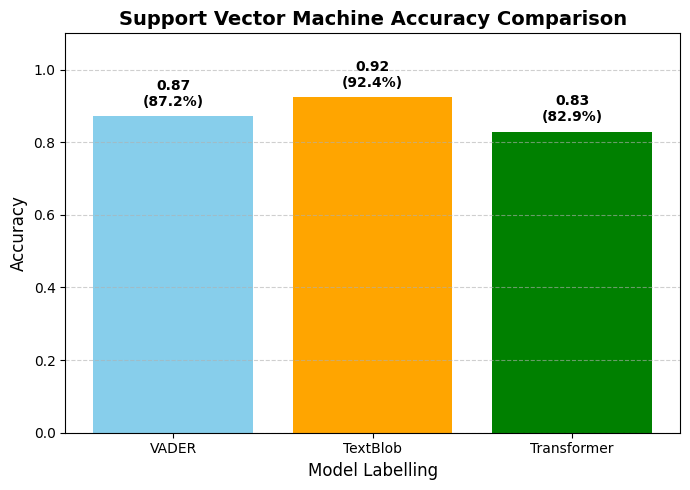

In [ ]:
SVM_Result = {
    'VADER': Vader_SVM[2],
    'TextBlob': TextBlob_SVM[2],
    'Transformer': Transformer_SVM[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(SVM_Result.keys(), SVM_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(SVM_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Support Vector Machine Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
result_svm = pd.DataFrame(SVM_Result, index=[0])
display(result_svm)

,VADER,TextBlob,Transformer
0,0.871909,0.924152,0.829061


In [ ]:
data = {
    "SVM": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5637,
    'precision': 0.7532,
    'f1_score': 0.5711,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5461,
    'precision': 0.7541,
    'f1_score': 0.5668,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5478,
    'precision': 0.7533,
    'f1_score': 0.5456,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.878, 0.8719, 0.8739],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8268, 0.8291, 0.8274],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.9256, 0.9242, 0.9245],
    'labels': 'Blob_Sentiment'}]}]

### **Deep Learning Model**

###### We’re going to build two deep learning models **BERT** and a **CNN for text** to train and compare performance across the **VADER**, **TextBlob**, and **Transformer** sentiment datasets.

###### Let make the copy of the dataset

In [ ]:
df = Dataset.copy()

#### **CNN for Text**

###### We’re training a **CNN-based deep learning model** for sentiment analysis. The text is tokenized, padded, and converted into embeddings so the model can learn meaningful word patterns. Using convolutional and dense layers, it classifies posts as **Positive**, **Negative**, or **Neutral**, while class weights ensure balanced learning and accurate evaluation results.

In [ ]:
general_results = []

In [ ]:
def train_cnn_sentiment_model(
    dataframe, sentiment_col, max_words=10000, max_len=200,
    embedding_dim=100, epochs=5, batch_size=64
):
    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    y = df['label_mapped'].values

    # Tokenize text data
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(df['text_lemma'])
    sequences = tokenizer.texts_to_sequences(df['text_lemma'])
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print("\nClass Weights:", class_weight_dict)

    # Build CNN model
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')  # 3 classes: Negative, Positive, Neutral
    ])

    # Compile model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    # Train model with class weights
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Evaluate model
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Build scores array [precision, accuracy, f1]
    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    # Build result object
    model_result = {
        "model_name": "CNN",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return model, tokenizer, accuracy, model_result

#### **CNN with Vader Sentiment**

In [ ]:
Vader_CNN = train_cnn_sentiment_model(Dataframe, 'vader_sentiment')


Class Weights: {0: np.float64(1.3457764289327263), 1: np.float64(0.5365843820587286), 2: np.float64(2.5426223241590216)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6352 - loss: 0.7848 - val_accuracy: 0.8559 - val_loss: 0.3950
Epoch 2/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8824 - loss: 0.3494 - val_accuracy: 0.8884 - val_loss: 0.3490
Epoch 3/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9092 - loss: 0.2743 - val_accuracy: 0.8903 - val_loss: 0.3245
Epoch 4/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9290 - loss: 0.2208 - val_accuracy: 0.8820 - val_loss: 0.3340
Epoch 5/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9464 - loss: 0.1690 - val_accuracy: 0.8779 - val_loss: 0.3721
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Accuracy: 0.8796
Precision (weighted): 0.8803
F1 Score (weighted): 0.8798

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80      3295
    Positive       0.92      0.92      0.92      8264
     Neutral       0.87      0.83      0.85      1744

    ac

#### **CNN with Transformer**

In [ ]:
Transformer_CNN = train_cnn_sentiment_model(Dataframe, 'sentiment')


Class Weights: {0: np.float64(1.6105814340627742), 1: np.float64(1.5916487197894233), 2: np.float64(0.5711586969355444)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


749/749 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6244 - loss: 0.7954 - val_accuracy: 0.8191 - val_loss: 0.4482
Epoch 2/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8446 - loss: 0.4147 - val_accuracy: 0.8324 - val_loss: 0.4120
Epoch 3/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8819 - loss: 0.3103 - val_accuracy: 0.8395 - val_loss: 0.4088
Epoch 4/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9150 - loss: 0.2236 - val_accuracy: 0.8279 - val_loss: 0.4541
Epoch 5/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9390 - loss: 0.1635 - val_accuracy: 0.8356 - val_loss: 0.4568
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Accuracy: 0.8333
Precision (weighted): 0.8412
F1 Score (weighted): 0.836

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.75      0.70      2753
    Positive       0.83      0.86      0.85      2786
     Neutral       0.91      0.85      0.88      7764

    accuracy      

#### **CNN with Text Blob**

In [ ]:
TextBlob_CNN = train_cnn_sentiment_model(Dataframe, 'Blob_Sentiment')


Class Weights: {0: np.float64(1.4480637875200697), 1: np.float64(0.5431403170325912), 2: np.float64(2.1354843887952484)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


749/749 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6572 - loss: 0.6899 - val_accuracy: 0.9094 - val_loss: 0.2523
Epoch 2/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9024 - loss: 0.2190 - val_accuracy: 0.8933 - val_loss: 0.2641
Epoch 3/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9329 - loss: 0.1565 - val_accuracy: 0.9030 - val_loss: 0.2412
Epoch 4/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9513 - loss: 0.1099 - val_accuracy: 0.9145 - val_loss: 0.2367
Epoch 5/5
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9676 - loss: 0.0776 - val_accuracy: 0.9136 - val_loss: 0.2701
416/416 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Accuracy: 0.9077
Precision (weighted): 0.9122
F1 Score (weighted): 0.9091

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.88      0.83      3063
    Positive       0.95      0.91      0.93      8164
     Neutral       0.96      0.93      0.95      2076

    accuracy     

#### **Comparison of the 4 for CNN**

###### Let’s visualize how well our **CNN models** performed! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** sentiment labelling, with percentage values displayed on each bar to clearly show which model achieved the best performance.

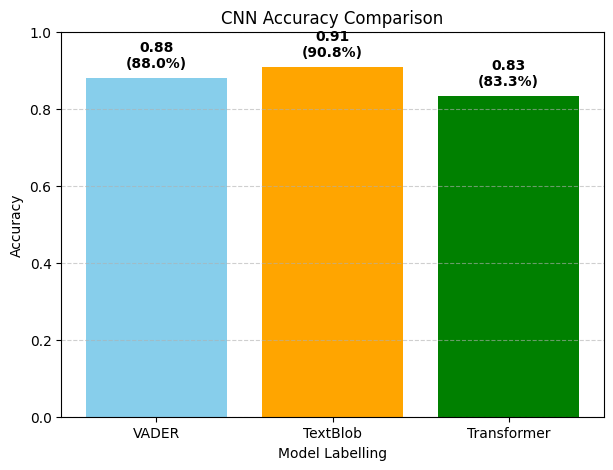

In [ ]:
CNN_Result = {
    'VADER': Vader_CNN[2],
    'TextBlob': TextBlob_CNN[2],
    'Transformer': Transformer_CNN[2],
}

plt.figure(figsize=(7,5))
ax = plt.bar(CNN_Result.keys(), CNN_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(CNN_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(CNN_Result.keys(), CNN_Result.values(), color=['skyblue','orange','green'])
plt.title("CNN Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s display the **CNN model results** in a clean table using a DataFrame. This makes it easy to compare the accuracies of **VADER**, **TextBlob**, and **Transformer** sentiment models side by side and identify which one performed best.

In [ ]:
result_CNN = pd.DataFrame(CNN_Result, index=[0])
display(result_CNN)

,VADER,TextBlob,Transformer
0,0.879576,0.90769,0.833271


In [ ]:
data = {
    "CNN": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5637,
    'precision': 0.7532,
    'f1_score': 0.5711,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5461,
    'precision': 0.7541,
    'f1_score': 0.5668,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5478,
    'precision': 0.7533,
    'f1_score': 0.5456,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.878, 0.8719, 0.8739],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8268, 0.8291, 0.8274],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.9256, 0.9242, 0.9245],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.8803, 0.8796, 0.8798],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

#### **Using Transformer BERT**

###### We’re fine-tuning a BERT model for sentiment analysis. We take the cleaned text, map each sentiment (Negative, Positive, Neutral) to numbers, split into train/test, tokenize with a pretrained BERT tokenizer, and train a sequence classification model. After training, we measure performance using accuracy, a classification report, and a confusion matrix.

In [ ]:
general_results = []

In [ ]:
class _SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


def train_bert_sentiment_model(
    dataframe,
    sentiment_col,
    text_col="text_lemma",
    model_name="bert-base-uncased",
    max_len=128,
    epochs=2,
    batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    random_state=42
):
    # Map labels
    label_map = {"Negative": 0, "Positive": 1, "Neutral": 2}
    df = dataframe[[text_col, sentiment_col]].dropna().copy()
    df["label_mapped"] = df[sentiment_col].map(label_map)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col].tolist(),
        df["label_mapped"].tolist(),
        test_size=0.2,
        stratify=df["label_mapped"],
        random_state=random_state
    )

    # Tokenizer & encodings
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_enc = tokenizer(
        X_train, truncation=True, padding=False, max_length=max_len
    )
    test_enc = tokenizer(
        X_test, truncation=True, padding=False, max_length=max_len
    )

    train_ds = _SimpleDataset(train_enc, y_train)
    test_ds = _SimpleDataset(test_enc, y_test)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3
    )

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    args = TrainingArguments(
        output_dir="bert_sentiment_outputs",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        report_to=[]
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
    )

    # Train
    trainer.train()

    # Predict
    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ["Negative", "Positive", "Neutral"]
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": f"BERT ({model_name})",
        "use_class_weight": False,
        "scores": scores_array,
        "labels": sentiment_col
    }

    # Push into global results
    general_results.append(model_result)

    return model, tokenizer, trainer, accuracy, model_result

#### **Transformer with Vader**

In [ ]:
Vader_BERT = train_bert_sentiment_model(Dataframe, 'vader_sentiment')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.333700,0.239390
2,0.166500,0.201740



Accuracy: 0.9441
Precision (weighted): 0.944
F1 Score (weighted): 0.9435

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92      3295
    Positive       0.95      0.98      0.96      8264
     Neutral       0.95      0.84      0.89      1778

    accuracy                           0.94     13337
   macro avg       0.94      0.91      0.92     13337
weighted avg       0.94      0.94      0.94     13337


Confusion Matrix:
[[3029  227   39]
 [ 155 8067   42]
 [ 120  163 1495]]


#### **Transformer with Transformer**

In [ ]:
Transformer_BERT = train_bert_sentiment_model(Dataframe, 'sentiment')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.362900,0.269722
2,0.203900,0.306393



Accuracy: 0.9015
Precision (weighted): 0.9038
F1 Score (weighted): 0.9023

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.84      0.81      2753
    Positive       0.89      0.92      0.91      2786
     Neutral       0.95      0.92      0.93      7798

    accuracy                           0.90     13337
   macro avg       0.88      0.89      0.88     13337
weighted avg       0.90      0.90      0.90     13337


Confusion Matrix:
[[2307  149  297]
 [ 119 2572   95]
 [ 490  164 7144]]


#### **Transformer with Transformer**

In [ ]:
TextBlob_BERT = train_bert_sentiment_model(Dataframe, 'Blob_Sentiment')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.310900,0.173955
2,0.143300,0.172281



Accuracy: 0.9525
Precision (weighted): 0.9525
F1 Score (weighted): 0.9525

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      3063
    Positive       0.96      0.97      0.97      8164
     Neutral       0.97      0.95      0.96      2110

    accuracy                           0.95     13337
   macro avg       0.95      0.94      0.94     13337
weighted avg       0.95      0.95      0.95     13337


Confusion Matrix:
[[2767  258   38]
 [ 204 7939   21]
 [  62   50 1998]]


#### **Comparison of the 3 for BERT**

###### Let’s visualize how well our **BERT models** performed across different sentiment labelling methods **VADER**, **TextBlob**, and **Transformer**. This bar chart compares their accuracy to reveal which dataset helped BERT achieve the best performance and most reliable predictions.


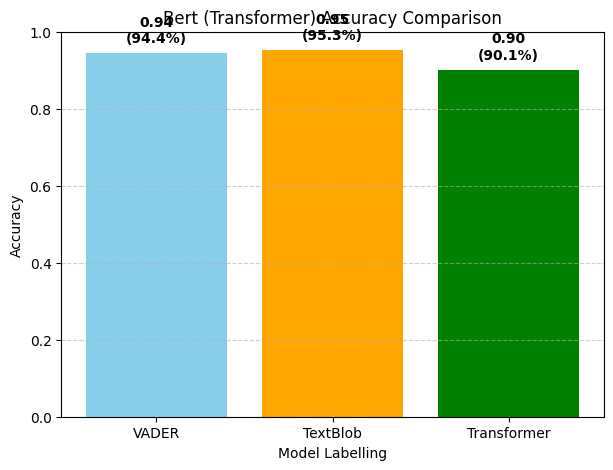

In [ ]:
BERT_Result = {
    'VADER': Vader_BERT[3],
    'TextBlob': TextBlob_BERT[3],
    'Transformer': Transformer_BERT[3]
}
plt.figure(figsize=(7,5))
ax = plt.bar(BERT_Result.keys(), BERT_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(BERT_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(BERT_Result.keys(), BERT_Result.values(), color=['skyblue','orange','green'])
plt.title("Bert (Transformer) Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s neatly display our **BERT model results** in a table using a DataFrame. This makes it easy to compare the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling side by side and identify which one produced the best overall performance.

In [ ]:
result_bert = pd.DataFrame(BERT_Result, index=[0])
display(result_bert)

,VADER,TextBlob,Transformer
0,0.944065,0.952538,0.901477


In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

#### **Overall comparison for the 4 Model to know the best model**

###### Here we’re bringing everything together! This dictionary stores the **accuracy results** of all four models — **Naive Bayes**, **SVM**, **CNN**, and **BERT**. for each sentiment labelling method (**VADER**, **TextBlob**, and **Transformer**) so we can easily compare their performances later.

In [ ]:
results = {
    "CNN": {"VADER": Vader_CNN[2], "TextBlob": TextBlob_CNN[2], "Transformer": Transformer_CNN[2]},
    "SVM": {"VADER": Vader_SVM[2], "TextBlob": TextBlob_SVM[2], "Transformer": Transformer_SVM[2]},
    "Naive Bayes": {"VADER": Vader_Naive_Bayes[2], "TextBlob": TextBlob_Naive_Bayes[2], "Transformer": Transformer_Naive_Bayes[2]},
    "BERT": {"VADER": Vader_BERT[3], "TextBlob": TextBlob_BERT[3], "Transformer": Transformer_BERT[3]},
}

###### Let’s organize all our model performances into a clean table! By converting the results dictionary into a DataFrame, we can easily compare how **Naive Bayes**, **SVM**, **CNN**, and **BERT** performed across **VADER**, **TextBlob**, and **Transformer** labels all neatly rounded for clarity.

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

display(results_df)

,VADER,TextBlob,Transformer
CNN,0.8796,0.9077,0.8333
SVM,0.8719,0.9242,0.8291
Naive Bayes,0.5637,0.5478,0.5461
BERT,0.9441,0.9525,0.9015


###### Let’s visualize the overall performance of all our models! This bar chart compares the accuracies of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across the three sentiment sources **VADER**, **TextBlob**, and **Transformer** to clearly see which combination performed best.

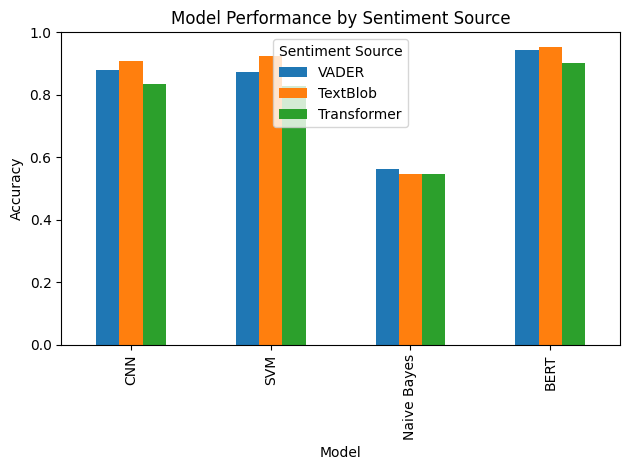

In [ ]:
ax = results_df.plot(kind='bar')
ax.set_title("Model Performance by Sentiment Source")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.legend(title="Sentiment Source", loc="best")
plt.tight_layout()
plt.show()

###### Let’s find out which model performed best for each sentiment source! This code checks the **highest accuracy** in each column and prints the **top-performing model** for **VADER**, **TextBlob**, and **Transformer** sentiment labelling.

In [ ]:
best_scores = results_df.idxmax()
print("Best models per sentiment source:")
print(best_scores)

Best models per sentiment source:
VADER          BERT
TextBlob       BERT
Transformer    BERT
dtype: object


###### Let’s create a **heatmap** to visualize model performance more clearly! Each cell shows the accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across **VADER**, **TextBlob**, and **Transformer** labels, making it easy to spot the strongest results at a glance.

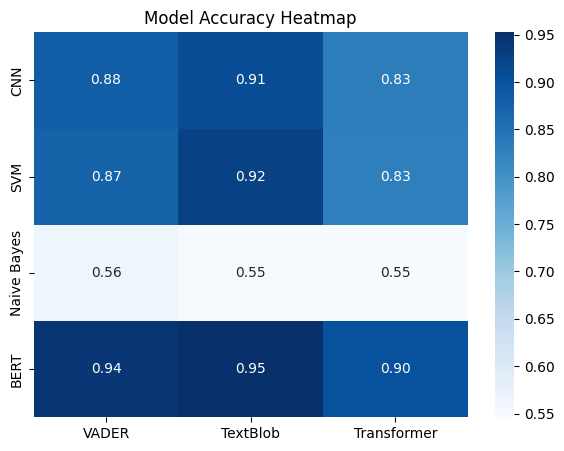

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(results_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Model Accuracy Heatmap")
plt.show()

##### **Overall Labelling**

###### Let’s calculate the **average accuracy** for each sentiment source across all models. This helps us see whether **VADER**, **TextBlob**, or **Transformer** generally provided better training data for sentiment prediction overall.

In [ ]:
avg_scores = results_df.mean().sort_values(ascending=False)
print(avg_scores)

TextBlob       0.833050
VADER          0.814825
Transformer    0.777500
dtype: float64


###### Let’s visualize the **average accuracy** of each sentiment source across all models! This bar chart clearly shows whether **VADER**, **TextBlob**, or **Transformer** produced better overall results when used to train different sentiment classifiers.

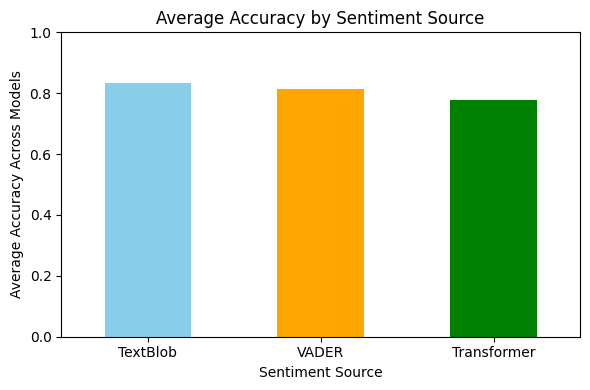

In [ ]:
plt.figure(figsize=(6,4))
avg_scores.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])

plt.title('Average Accuracy by Sentiment Source')
plt.xlabel('Sentiment Source')
plt.ylabel('Average Accuracy Across Models')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s identify the **best overall sentiment source** This code finds which dataset **VADER**, **TextBlob**, or **Transformer** achieved the **highest average accuracy** across all models, then prints the top performer along with its exact score.

In [ ]:
best_source = avg_scores.idxmax()
best_score = avg_scores.max()
print(f"Best performing sentiment source: {best_source} ({best_score:.3f})")

Best performing sentiment source: TextBlob (0.833)


#### **For Model**

###### Let’s now check which **model** performed best on average across all sentiment sources. This code calculates the mean accuracy for each model  **Naive Bayes**, **SVM**, **CNN**, and **BERT** helping us see which one delivered the most consistent overall performance.

In [ ]:
avg_model_scores = results_df.mean(axis=1).sort_values(ascending=False)
print(avg_model_scores)

BERT           0.932700
SVM            0.875067
CNN            0.873533
Naive Bayes    0.552533
dtype: float64


###### Let’s visualize how each **model** performed on average across all sentiment sources! This bar chart compares the overall accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT**, helping us easily see which model achieved the strongest and most reliable performance.

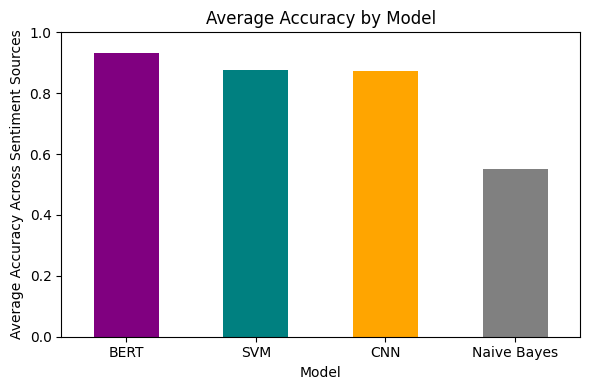

In [ ]:
plt.figure(figsize=(6,4))
avg_model_scores.plot(kind='bar', color=['purple', 'teal', 'orange', 'gray'])

plt.title('Average Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Average Accuracy Across Sentiment Sources')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s find out which **model** performed the best overall! This code identifies the model whether **Naive Bayes**, **SVM**, **CNN**, or **BERT** with the **highest average accuracy** across all sentiment sources and prints it along with its exact score.

In [ ]:
best_model = avg_model_scores.idxmax()
best_score = avg_model_scores.max()
print(f"Best performing model overall: {best_model} ({best_score:.3f})")

Best performing model overall: BERT (0.933)


###### Let’s save our cleaned and processed dataset! This line exports the entire **DataFrame** to a CSV file named **“Updated_Data.csv”**, excluding the index column, so we can easily reuse it for future analysis or modeling.

In [ ]:
Dataframe.to_csv('Updated_Data.csv', index=False)

In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5637,
    'precision': 0.7532,
    'f1_score': 0.5711,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5461,
    'precision': 0.7541,
    'f1_score': 0.5668,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5478,
    'precision': 0.7533,
    'f1_score': 0.5456,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.878, 0.8719, 0.8739],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8268, 0.8291, 0.8274],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.9256, 0.9242, 0.9245],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.8803, 0.8796, 0.8798],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

In [ ]:
with open("model_results.json", "r") as f:
    data = json.load(f)

print(data)

{'2020': [{'Naive Bayes': [{'accuracy': 0.6849, 'precision': 0.7254, 'f1_score': 0.7022, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.609, 'precision': 0.6354, 'f1_score': 0.6131, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7092, 'precision': 0.7184, 'f1_score': 0.7123, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]}, {'SVM': [{'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8061, 0.8094, 0.8077], 'labels': 'vader_sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.712, 0.7134, 0.7124], 'labels': 'sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8294, 0.8303, 0.8297], 'labels': 'Blob_Sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7618, 0.7578, 0.7597], 'labels': 'vader_sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7418, 0.7339, 0.7361], 'labels': 'sentiment'}, {'model_name': 'CNN', 'use_class_weight': 

In [ ]:
data['2025'] = Result_global

with open("model_results.json", "w") as file:
    json.dump(data, file, indent=4)

print("Result Saved Successfully")

Result Saved Successfully


### **Topic Modelling**

###### Topic modelling helps uncover hidden themes in text data, like identifying key reasons behind employee concerns in a **job dissatisfaction** dataset.

#### **LDA - Latent Dirichlet Allocation**

In [ ]:
data = pd.read_csv('2025_JOB_Dissatisfaction_Sentiment.csv')

In [4]:
display(data)

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,...,Blob_Sentiment,neg,neu,pos,sentiment,all_agree,two_or_more_agree,vader_strength,textblob_strength,transformer_strength
0,1ltd0pl,UKJobs,1.751838e+09,Is there a correlation between unemployment an...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1ltd0...,is there a correlation between unemployment an...,...,Positive,0.131145,0.563207,0.020800,Neutral,False,False,0.9201,0.034020,0.563207
1,1l28f88,UKJobs,1.748947e+09,Me and a colleague have been shortlisted for s...,11,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1l28f...,me and a colleague have been shortlisted for s...,...,Positive,0.028519,0.104343,0.741285,Positive,True,True,0.2516,0.262500,0.741285
2,1k1kp8i,UKJobs,1.744916e+09,Looking for advice Going to try condense this ...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1k1kp...,looking for advice going to try condense this ...,...,Negative,0.101022,0.275913,0.036717,Negative,False,False,0.5367,0.022313,0.275913
3,1p6jdj5,UKJobs,1.764093e+09,Struggling to pick a career path because I fee...,3,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6jd...,struggling to pick a career path because i fee...,...,Positive,0.646834,0.135267,0.118361,Negative,False,False,0.8779,0.091667,0.646834
4,1p6cgeh,UKJobs,1.764077e+09,I hate my new job and am thinking to leave I s...,25,hate my job,Negative,post,https://www.reddit.com/r/UKJobs/comments/1p6cg...,i hate my new job and am thinking to leave i s...,...,Negative,0.213474,0.009691,0.017493,Negative,True,True,0.9473,0.197931,0.213474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66679,mpohzj4,recruitinghell,1.745943e+09,Companies cheat and auto reject anyone without...,4,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,companies cheat and auto reject anyone without...,...,Positive,0.013302,0.672179,0.006329,Neutral,False,False,0.2960,0.250000,0.672179
66680,mpo87od,recruitinghell,1.745940e+09,"Good luck, OP. Sounds just like what happened...",3,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,good luck op sounds just like what happened to...,...,Positive,0.012237,0.213887,0.759691,Positive,True,True,0.8126,0.550000,0.759691
66681,mcf4fyu,recruitinghell,1.739389e+09,The discord for our subreddit can be found her...,1,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,the discord for our subreddit can be found her...,...,Positive,0.024111,0.896784,0.007900,Neutral,False,False,0.6249,0.250000,0.896784
66682,mcimio9,recruitinghell,1.739433e+09,Yeah it's terrible. I'm in London and have bee...,2,flexible working,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,yeah it's terrible i'm in london and have been...,...,Negative,0.067321,0.018909,0.531621,Positive,False,False,0.2263,0.500000,0.531621


#### **LDA**

#### Let's converts the lemmatised text into a numerical bag-of-words representation using CountVectorizer. English stop words are removed to reduce noise and any missing values are replaced with empty strings to avoid errors during transformation.

In [5]:
# Convert the lemmatized text into a numerical feature matrix using Bag-of-Words,
# while removing common English stop words (e.g., "the", "and", "is")
vectorizer = CountVectorizer(stop_words='english')

# Fit the vectorizer to the text data and transform it into numeric form
X = vectorizer.fit_transform(data['text_lemma'].fillna(''))

### **Getting the Perplexity Score**

##### We are going to test different numbers of topics to see which one works best with our data. For each value between 1 and 10, we train an LDA model and record its perplexity score. We then plot these scores so we can clearly see where the model performs best. Since lower perplexity means better topic quality, the point where the curve levels out helps us decide the most suitable number of topics for our analysis.

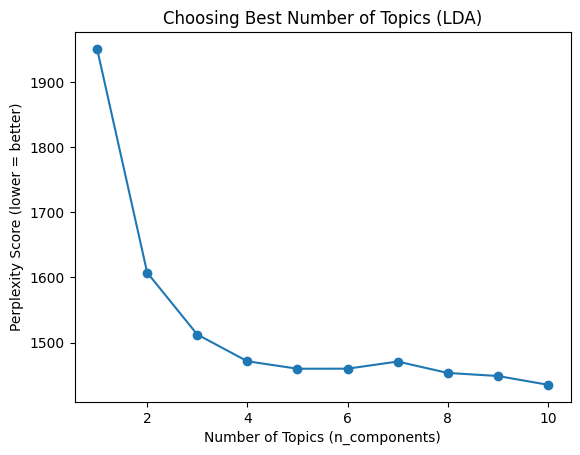

In [6]:
scores = []
topics = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for n in topics:
    lda = LatentDirichletAllocation(n_components=n, random_state=42)
    lda.fit(X)
    score = lda.perplexity(X)
    scores.append(score)

plt.plot(topics, scores, marker='o')
plt.title("Choosing Best Number of Topics (LDA)")
plt.xlabel("Number of Topics (n_components)")
plt.ylabel("Perplexity Score (lower = better)")
plt.show()

##### Train the LDA model with 3 topics, then extract and display the top 10 most important words for each topic.

In [7]:
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out()
num_words = 10

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-num_words:]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: make, thing, feel, good, year, life, time, people, like, work
Topic 2: salary, wage, money, london, cost, work, year, uk, people, pay
Topic 3: look, like, want, time, pay, company, year, role, work, job
Topic 4: government, require, apply, wale, scotland, reading, england, member, present, private
Topic 5: issue, know, people, health, like, help, ask, make, say, need
Topic 6: like, card, driver, train, phone, people, pay, drive, car, use
Topic 7: office, tell, manager, leave, say, time, hour, week, day, work
Topic 8: break, contact, joke, rule, answer, comment, askuk, subreddit, help, question
Topic 9: need, good, day, look, food, buy, make, house, use, like
Topic 10: site, reddit, thread, megathread, ukjob, moderator, subreddit, help, message, post


#### Get the topic probability distribution for each document in the dataset.

In [8]:
doc_topic_dist = lda.transform(X)

##### Assign each document to the topic with the highest probability.

In [9]:
data['topic_LDA'] = doc_topic_dist.argmax(axis=1)

##### Create and display a dictionary that assigns meaningful names to each LDA topic.

In [14]:
Topic_suggestion = {
    "Topic 1": "General life & work satisfaction",
    "Topic 2": "Salary, pay & cost of living",
    "Topic 3": "Jobs, roles & career decisions",
    "Topic 4": "Government, rules & legal requirements",
    "Topic 5": "Health issues & asking for help",
    "Topic 6": "Transport, driving & daily payments",
    "Topic 7": "Office work, managers & working hours",
    "Topic 8": "Reddit advice, jokes & rule-based questions",
    "Topic 9": "Daily life, food & home activities",
    "Topic 10": "Reddit moderation & job megathreads"
}

print(Topic_suggestion)

{'Topic 1': 'General life & work satisfaction', 'Topic 2': 'Salary, pay & cost of living', 'Topic 3': 'Jobs, roles & career decisions', 'Topic 4': 'Government, rules & legal requirements', 'Topic 5': 'Health issues & asking for help', 'Topic 6': 'Transport, driving & daily payments', 'Topic 7': 'Office work, managers & working hours', 'Topic 8': 'Reddit advice, jokes & rule-based questions', 'Topic 9': 'Daily life, food & home activities', 'Topic 10': 'Reddit moderation & job megathreads'}


In [15]:
topic_label_map = {i: Topic_suggestion[f"Topic {i+1}"] for i in range(10)}
data['topic_label_LDA'] = data['topic_LDA'].map(topic_label_map)

##### Let's group the data by topic and sentiment, then count how many records fall into each group.

In [16]:
sentiment_summary = (
    data.groupby(['topic_label_LDA', 'sentiment'])
      .size()
      .reset_index(name='count')
)
display(sentiment_summary)

,topic_label_LDA,sentiment,count
0,"Daily life, food & home activities",Negative,1405
1,"Daily life, food & home activities",Neutral,3734
2,"Daily life, food & home activities",Positive,772
3,General life & work satisfaction,Negative,3750
4,General life & work satisfaction,Neutral,5781
5,General life & work satisfaction,Positive,3298
6,"Government, rules & legal requirements",Negative,82
7,"Government, rules & legal requirements",Neutral,550
8,"Government, rules & legal requirements",Positive,32
9,Health issues & asking for help,Negative,1066


###### Let draw a chat to show the relationship among the two of them

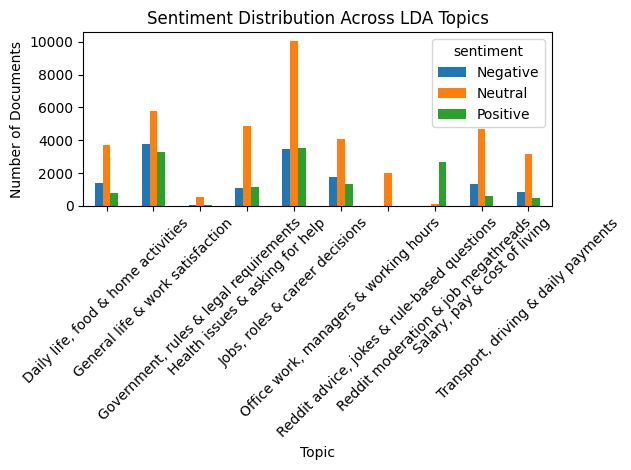

In [17]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

# Plot the bar chart
pivot_table.plot(kind='bar')

plt.title("Sentiment Distribution Across LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Create the Table**

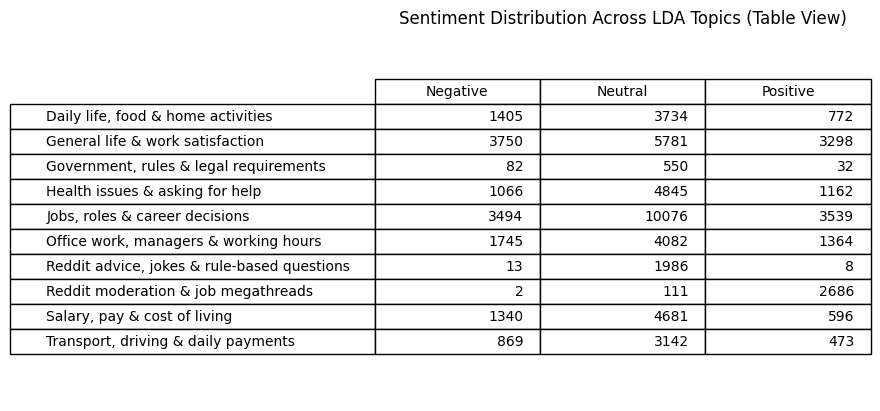

In [18]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    rowLabels=pivot_table.index,
    loc='center'
)

table.scale(1, 1.5)

plt.title("Sentiment Distribution Across LDA Topics (Table View)")
plt.show()

##### Let's build a Gensim LDA model and evaluate its topic quality using the coherence score.

In [19]:
corpus = [vectorizer.inverse_transform(x)[0] for x in X]
dictionary = Dictionary(corpus)

bow_corpus = [dictionary.doc2bow(doc) for doc in corpus]

lda_gensim = LdaModel(bow_corpus, num_topics=7, id2word=dictionary, passes=15, random_state=42)


coherence_model = CoherenceModel(model=lda_gensim, texts=corpus, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.7298149691158983


In [20]:
lda_json = {}

for _, row in sentiment_summary.iterrows():
    topic = row["topic_label_LDA"]
    sentiment = row["sentiment"]
    count = int(row["count"])

    if topic not in lda_json:
        lda_json[topic] = {}

    lda_json[topic][sentiment] = count


final_lda_json = {
    "LDA_Sentiment_Summary": lda_json
}
print(final_lda_json)

{'LDA_Sentiment_Summary': {'Daily life, food & home activities': {'Negative': 1405, 'Neutral': 3734, 'Positive': 772}, 'General life & work satisfaction': {'Negative': 3750, 'Neutral': 5781, 'Positive': 3298}, 'Government, rules & legal requirements': {'Negative': 82, 'Neutral': 550, 'Positive': 32}, 'Health issues & asking for help': {'Negative': 1066, 'Neutral': 4845, 'Positive': 1162}, 'Jobs, roles & career decisions': {'Negative': 3494, 'Neutral': 10076, 'Positive': 3539}, 'Office work, managers & working hours': {'Negative': 1745, 'Neutral': 4082, 'Positive': 1364}, 'Reddit advice, jokes & rule-based questions': {'Negative': 13, 'Neutral': 1986, 'Positive': 8}, 'Reddit moderation & job megathreads': {'Negative': 2, 'Neutral': 111, 'Positive': 2686}, 'Salary, pay & cost of living': {'Negative': 1340, 'Neutral': 4681, 'Positive': 596}, 'Transport, driving & daily payments': {'Negative': 869, 'Neutral': 3142, 'Positive': 473}}}


#### **Bertopic**

##### BERTopic is a topic modeling technique that uses BERT embeddings to generate coherent and meaningful topics from large text datasets.

##### Download the list of common stopwords used for text preprocessing

In [21]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##### Let's removes automated moderator messages using predefined text patterns and keeps only genuine user-generated content for analysis.

In [22]:
patterns_to_remove = [
    "thank posting",
    "please help keep",
    "welcoming",
    "moderators",
    "megathread",
    "submissionpost",
    "automatically",
    "contact the moderators",
    "if you have a concern",
    "replying submissionpost",
    "help us make better",
]


def remove_auto_mod(text):
    for p in patterns_to_remove:
        if p in text.lower():
            return None
    return text

data["filtered_text"] = data["text_raw"].apply(remove_auto_mod)
data = data.dropna(subset=["filtered_text"])
documents = data["filtered_text"].tolist()

##### Let's converts the cleaned text column into a list of documents for further analysis.

In [23]:
documents = data["filtered_text"].tolist()

##### Let's set up and runs a customized BERTopic pipeline using Sentence-BERT embeddings, CountVectorizer, UMAP for dimensionality reduction, and HDBSCAN for clustering to generate well-separated, fine-grained topics from the text documents.

In [26]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10
)

#UMAP – more separation, more topics
umap_model = UMAP(
    n_neighbors=5,
    n_components=15,
    min_dist=0.0,
    random_state=42
)

# HDBSCAN – allow smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=10,
    nr_topics=None
)

topics, probs = topic_model.fit_transform(documents)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Let retrieves a summary table of all discovered topics, including their sizes and labels.

In [27]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24301,-1_job_work_just_like,"[job, work, just, like, don, people, ve, time,...",[About to leave a job of 15 years for a totall...
1,0,1243,0_tomorrow_today_bed_sleep,"[tomorrow, today, bed, sleep, tonight, day, ni...",[Was going to have a few beers last night beca...
2,1,1032,1_sick_health_stress_note,"[sick, health, stress, note, sick leave, menta...","[>I never take sick days\n\nWhy wouldn't you, ..."
3,2,702,2_congratulations_congrats_hope_thank,"[congratulations, congrats, hope, thank, op, l...","[Congratulations!!!!! Hurray!!, Congratulation..."
4,3,659,3_wage_minimum wage_minimum_wages,"[wage, minimum wage, minimum, wages, salaries,...",[As you're now seeing - there's no winning.\n\...
5,4,643,4_mortgage_debt_savings_money,"[mortgage, debt, savings, money, house, income...","[The sooner I pay off my mortgage, the sooner ..."
6,5,604,5_manchester_city_london_north,"[manchester, city, london, north, liverpool, b...",[Feeling stuck in Hull — is moving to a bigger...
7,6,580,6_cheese_jam_toast_sandwich,"[cheese, jam, toast, sandwich, sugar, milk, pr...","[I mean, macaroni cheese has never been a heal..."
8,7,567,7_apprenticeship_engineering_apprenticeships_e...,"[apprenticeship, engineering, apprenticeships,...","[Apprenticeship, What was the apprenticeship i..."
9,8,565,8_noise_neighbour_neighbours_loud,"[noise, neighbour, neighbours, loud, council, ...",[What is considered an unreasonable amount of ...


##### Let extracts the top keywords for each topic and stores them in a dictionary for easy access and analysis.

In [28]:
topics_dict = topic_model.get_topics()

topic_words = {}

for topic_id, words in topics_dict.items():
    topic_words[topic_id] = [w for w, _ in words]

##### Let tokenizes each document by splitting it into a list of individual words.

In [29]:
texts = [doc.split() for doc in documents]

##### This line creates a Gensim dictionary that maps each unique word in the documents to a numerical ID.

In [30]:
dictionary = Dictionary(texts)

##### Let calculates the coherence score for each topic using only valid words from the dictionary, helping to evaluate how meaningful and consistent each topic is.

In [31]:
topic_coherence = {}

for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]

    if filtered_words:
        cm = CoherenceModel(
            topics=[filtered_words],
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        topic_coherence[topic_id] = cm.get_coherence()
    else:
        topic_coherence[topic_id] = None

##### Let's converts the topic coherence scores into a DataFrame, sorts them in descending order, and displays the top 15 most coherent topics.

In [32]:
df_coh = pd.DataFrame({
    "topic": list(topic_coherence.keys()),
    "coherence": list(topic_coherence.values())
})

df_coh_sorted = df_coh.sort_values("coherence", ascending=False)
df_coh_sorted.head(15)

,topic,coherence
51,50,0.842176
105,104,0.775587
9,8,0.775254
42,41,0.770242
63,62,0.752504
30,29,0.742636
100,99,0.737753
131,130,0.724878
130,129,0.714380
132,131,0.707108


##### Calculate overall coherence using the filtered topic words

In [33]:
filtered_global_topic_words = []
for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]
    if filtered_words:
        filtered_global_topic_words.append(filtered_words)
cm_global = CoherenceModel(
    topics=filtered_global_topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

overall_coherence = cm_global.get_coherence()
print("Overall coherence:", overall_coherence)

Overall coherence: 0.49648039572490216


In [34]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24301,-1_job_work_just_like,"[job, work, just, like, don, people, ve, time,...",[About to leave a job of 15 years for a totall...
1,0,1243,0_tomorrow_today_bed_sleep,"[tomorrow, today, bed, sleep, tonight, day, ni...",[Was going to have a few beers last night beca...
2,1,1032,1_sick_health_stress_note,"[sick, health, stress, note, sick leave, menta...","[>I never take sick days\n\nWhy wouldn't you, ..."
3,2,702,2_congratulations_congrats_hope_thank,"[congratulations, congrats, hope, thank, op, l...","[Congratulations!!!!! Hurray!!, Congratulation..."
4,3,659,3_wage_minimum wage_minimum_wages,"[wage, minimum wage, minimum, wages, salaries,...",[As you're now seeing - there's no winning.\n\...
5,4,643,4_mortgage_debt_savings_money,"[mortgage, debt, savings, money, house, income...","[The sooner I pay off my mortgage, the sooner ..."
6,5,604,5_manchester_city_london_north,"[manchester, city, london, north, liverpool, b...",[Feeling stuck in Hull — is moving to a bigger...
7,6,580,6_cheese_jam_toast_sandwich,"[cheese, jam, toast, sandwich, sugar, milk, pr...","[I mean, macaroni cheese has never been a heal..."
8,7,567,7_apprenticeship_engineering_apprenticeships_e...,"[apprenticeship, engineering, apprenticeships,...","[Apprenticeship, What was the apprenticeship i..."
9,8,565,8_noise_neighbour_neighbours_loud,"[noise, neighbour, neighbours, loud, council, ...",[What is considered an unreasonable amount of ...


##### This code assigns meaningful, human-readable labels to selected topics to improve the interpretability of the BERTopic model results.

In [35]:
topic_labels = {
    -1: "Job quitting & long-term work decisions",
    0: "Sleep, nights & daily routines",
    1: "Mental health, sickness & workplace stress",
    2: "Congratulations, support & positive reactions",
    3: "Minimum wage & salary debates",
    4: "Mortgages, debt & personal finance",
    5: "UK cities & relocation",
    6: "Food, sandwiches & daily eating",
    7: "Apprenticeships & engineering careers",
    8: "Neighbour noise & council complaints"
}

topic_model.set_topic_labels(topic_labels)

##### This displays the top 10 topics along with their updated labels, sizes, and key information after topic labeling.

In [36]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,24301,-1_job_work_just_like,Job quitting & long-term work decisions,"[job, work, just, like, don, people, ve, time,...",[About to leave a job of 15 years for a totall...
1,0,1243,0_tomorrow_today_bed_sleep,"Sleep, nights & daily routines","[tomorrow, today, bed, sleep, tonight, day, ni...",[Was going to have a few beers last night beca...
2,1,1032,1_sick_health_stress_note,"Mental health, sickness & workplace stress","[sick, health, stress, note, sick leave, menta...","[>I never take sick days\n\nWhy wouldn't you, ..."
3,2,702,2_congratulations_congrats_hope_thank,"Congratulations, support & positive reactions","[congratulations, congrats, hope, thank, op, l...","[Congratulations!!!!! Hurray!!, Congratulation..."
4,3,659,3_wage_minimum wage_minimum_wages,Minimum wage & salary debates,"[wage, minimum wage, minimum, wages, salaries,...",[As you're now seeing - there's no winning.\n\...
5,4,643,4_mortgage_debt_savings_money,"Mortgages, debt & personal finance","[mortgage, debt, savings, money, house, income...","[The sooner I pay off my mortgage, the sooner ..."
6,5,604,5_manchester_city_london_north,UK cities & relocation,"[manchester, city, london, north, liverpool, b...",[Feeling stuck in Hull — is moving to a bigger...
7,6,580,6_cheese_jam_toast_sandwich,"Food, sandwiches & daily eating","[cheese, jam, toast, sandwich, sugar, milk, pr...","[I mean, macaroni cheese has never been a heal..."
8,7,567,7_apprenticeship_engineering_apprenticeships_e...,Apprenticeships & engineering careers,"[apprenticeship, engineering, apprenticeships,...","[Apprenticeship, What was the apprenticeship i..."
9,8,565,8_noise_neighbour_neighbours_loud,Neighbour noise & council complaints,"[noise, neighbour, neighbours, loud, council, ...",[What is considered an unreasonable amount of ...


##### Merging the topic with sentiment and drawing a chart

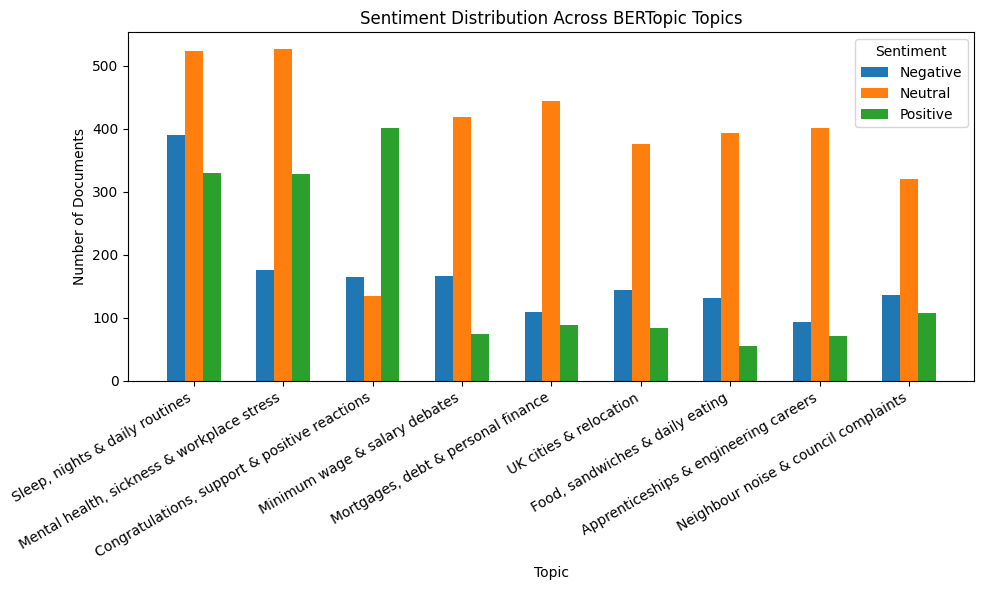

In [37]:
data = data.reset_index(drop=True)

data["topic_id"] = topics
data["topic_label"] = data["topic_id"].map(topic_labels)

data_plot = data[data["topic_id"] != -1].copy()

sent_counts = (
    data_plot.groupby(["topic_label", "sentiment"])
             .size()
             .reset_index(name="count")
)

sent_pivot = sent_counts.pivot(
    index="topic_label",
    columns="sentiment",
    values="count"
).fillna(0)

topic_order_df = (
    data_plot[["topic_id", "topic_label"]]
    .drop_duplicates()
    .sort_values("topic_id")
)

topic_order_df = topic_order_df.dropna(subset=['topic_label'])
sent_pivot = sent_pivot.loc[topic_order_df["topic_label"]]

topics_list = sent_pivot.index.tolist()
sentiments = sent_pivot.columns.tolist()

x = np.arange(len(topics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(sentiments):
    ax.bar(
        x + (i - (len(sentiments)-1)/2) * width,
        sent_pivot[s].values,
        width,
        label=s
    )

ax.set_xticks(x)
ax.set_xticklabels(topics_list, rotation=30, ha="right")
ax.set_ylabel("Number of Documents")
ax.set_xlabel("Topic")
ax.set_title("Sentiment Distribution Across BERTopic Topics")
ax.legend(title="Sentiment")

plt.tight_layout()
plt.show()

##### Creating a JSON File to get the topic

In [38]:
bertopic_json = {}

for topic_id, words in topic_words.items():

    if topic_id not in data["topic_id"].values:
        continue
    topic_name = topic_labels.get(topic_id, f"Topic {topic_id}")
    doc_count = int((data["topic_id"] == topic_id).sum())
    coherence_score = topic_coherence.get(topic_id)
    sentiment_dist = (
        data[data["topic_id"] == topic_id]["sentiment"]
        .value_counts()
        .to_dict()
    )
    bertopic_json[f"topic_{topic_id}"] = {
        "topic_id": int(topic_id),
        "topic_label": topic_name,
        "top_words": words[:10],
        "document_count": doc_count,
        "coherence_score": coherence_score,
        "sentiment_distribution": sentiment_dist
    }

final_json = {
    "Bertopic": bertopic_json
}

print(final_json)

{'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'Job quitting & long-term work decisions', 'top_words': ['job', 'work', 'just', 'like', 'don', 'people', 've', 'time', 'want', 'years'], 'document_count': 24301, 'coherence_score': np.float64(0.3306395221348213), 'sentiment_distribution': {'Neutral': 14567, 'Negative': 5545, 'Positive': 4189}}, 'topic_0': {'topic_id': 0, 'topic_label': 'Sleep, nights & daily routines', 'top_words': ['tomorrow', 'today', 'bed', 'sleep', 'tonight', 'day', 'night', 'morning', 'watching', 'got'], 'document_count': 1243, 'coherence_score': np.float64(0.5307360721615069), 'sentiment_distribution': {'Neutral': 523, 'Negative': 390, 'Positive': 330}}, 'topic_1': {'topic_id': 1, 'topic_label': 'Mental health, sickness & workplace stress', 'top_words': ['sick', 'health', 'stress', 'note', 'sick leave', 'mental', 'mental health', 'sickness', 'gp', 'signed'], 'document_count': 1032, 'coherence_score': np.float64(0.6486982522474161), 'sentiment_distribution'

##### Collapse Both LDA and Bertopic result for later exploration

In [39]:
data_final =  {
    "2025": {
        "LDA": final_lda_json,
        "Bertopic": final_json
    }
}

print(data_final)

{'2025': {'LDA': {'LDA_Sentiment_Summary': {'Daily life, food & home activities': {'Negative': 1405, 'Neutral': 3734, 'Positive': 772}, 'General life & work satisfaction': {'Negative': 3750, 'Neutral': 5781, 'Positive': 3298}, 'Government, rules & legal requirements': {'Negative': 82, 'Neutral': 550, 'Positive': 32}, 'Health issues & asking for help': {'Negative': 1066, 'Neutral': 4845, 'Positive': 1162}, 'Jobs, roles & career decisions': {'Negative': 3494, 'Neutral': 10076, 'Positive': 3539}, 'Office work, managers & working hours': {'Negative': 1745, 'Neutral': 4082, 'Positive': 1364}, 'Reddit advice, jokes & rule-based questions': {'Negative': 13, 'Neutral': 1986, 'Positive': 8}, 'Reddit moderation & job megathreads': {'Negative': 2, 'Neutral': 111, 'Positive': 2686}, 'Salary, pay & cost of living': {'Negative': 1340, 'Neutral': 4681, 'Positive': 596}, 'Transport, driving & daily payments': {'Negative': 869, 'Neutral': 3142, 'Positive': 473}}}, 'Bertopic': {'Bertopic': {'topic_-1': 

In [40]:
with open("2025_topic_model_master.json", "w", encoding="utf-8") as f:
    json.dump(data_final, f, indent=4, ensure_ascii=False)

print("Master JSON saved as topic_model_master.json")

Master JSON saved as topic_model_master.json
